In [1]:
import pandas as pd

print(pd.__version__)

2.3.3


In [2]:
train_df = pd.read_csv("../data/raw/fraudTrain.csv")
test_df = pd.read_csv("../data/raw/fraudTest.csv")

In [3]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (1296675, 23)
Testing shape: (555719, 23)


In [4]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
train_df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [7]:
train_df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

In [8]:
train_df.isnull().sum()


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
test_df.duplicated().sum()

np.int64(0)

In [11]:
print("Duplicate transaction numbers:", train_df["trans_num"].duplicated().sum())

Duplicate transaction numbers: 0


In [12]:
train_df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [13]:
train_df.nunique().sort_values()

gender                         2
is_fraud                       2
category                      14
state                         51
first                        352
last                         481
job                          494
merchant                     693
city_pop                     879
city                         894
lat                          968
dob                          968
long                         969
zip                          970
street                       983
cc_num                       983
amt                        52928
merch_lat                1247805
trans_date_trans_time    1274791
unix_time                1274823
merch_long               1275745
Unnamed: 0               1296675
trans_num                1296675
dtype: int64

In [14]:
train_df.groupby("is_fraud")["amt"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


In [15]:
train_df.groupby("category")["is_fraud"].agg(["count", "sum"])

,count,sum
category,,
entertainment,94014,233
food_dining,91461,151
gas_transport,131659,618
grocery_net,45452,134
grocery_pos,123638,1743
health_fitness,85879,133
home,123115,198
kids_pets,113035,239
misc_net,63287,915


In [16]:
category_fraud_rate = (
    train_df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

category_fraud_rate

category
shopping_net      0.017561
misc_net          0.014458
grocery_pos       0.014098
shopping_pos      0.007225
gas_transport     0.004694
misc_pos          0.003139
grocery_net       0.002948
travel            0.002864
entertainment     0.002478
personal_care     0.002424
kids_pets         0.002114
food_dining       0.001651
home              0.001608
health_fitness    0.001549
Name: is_fraud, dtype: float64

In [17]:
category_fraud_rate = (
    train_df.groupby("category")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

category_fraud_rate

category
shopping_net      1.756149
misc_net          1.445795
grocery_pos       1.409761
shopping_pos      0.722538
gas_transport     0.469394
misc_pos          0.313853
grocery_net       0.294817
travel            0.286370
entertainment     0.247835
personal_care     0.242403
kids_pets         0.211439
food_dining       0.165098
home              0.160825
health_fitness    0.154869
Name: is_fraud, dtype: float64

In [18]:
import matplotlib.pyplot as plt

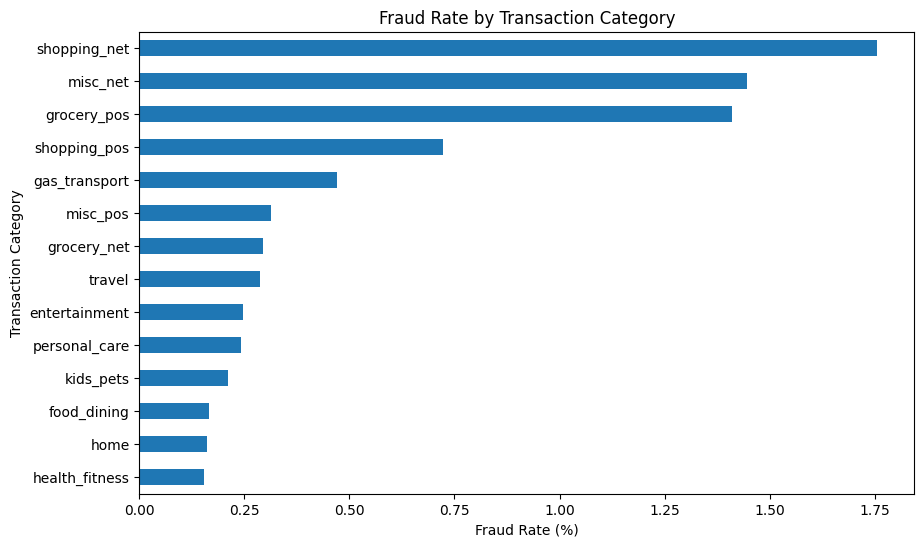

In [19]:
category_fraud_rate.sort_values().plot(kind="barh", figsize=(10, 6))

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")
plt.title("Fraud Rate by Transaction Category")
plt.show()

In [20]:
train_df["trans_date_trans_time"].head()

0    2019-01-01 00:00:18
1    2019-01-01 00:00:44
2    2019-01-01 00:00:51
3    2019-01-01 00:01:16
4    2019-01-01 00:03:06
Name: trans_date_trans_time, dtype: object

In [21]:
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

In [22]:
train_df["transaction_hour"] = train_df["trans_date_trans_time"].dt.hour

In [23]:
train_df[["trans_date_trans_time", "transaction_hour"]].head()

,trans_date_trans_time,transaction_hour
0,2019-01-01 00:00:18,0
1,2019-01-01 00:00:44,0
2,2019-01-01 00:00:51,0
3,2019-01-01 00:01:16,0
4,2019-01-01 00:03:06,0


In [24]:
hourly_fraud_rate = (
    train_df.groupby("transaction_hour")["is_fraud"]
    .mean()
    .mul(100)
)

hourly_fraud_rate

transaction_hour
0     1.494047
1     1.534909
2     1.465210
3     1.423929
4     0.109882
5     0.142278
6     0.094563
7     0.132692
8     0.115281
9     0.111414
10    0.094628
11    0.099805
12    0.102671
13    0.122485
14    0.132542
15    0.120812
16    0.115632
17    0.119175
18    0.122633
19    0.123649
20    0.095241
21    0.112920
22    2.882864
23    2.837387
Name: is_fraud, dtype: float64

In [25]:
hourly_analysis = (
    train_df.groupby("transaction_hour")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

hourly_analysis["fraud_rate"] = hourly_analysis["mean"] * 100

hourly_analysis

,count,sum,mean,fraud_rate
transaction_hour,,,,
0,42502,635,0.014940,1.494047
1,42869,658,0.015349,1.534909
2,42656,625,0.014652,1.465210
3,42769,609,0.014239,1.423929
4,41863,46,0.001099,0.109882
5,42171,60,0.001423,0.142278
6,42300,40,0.000946,0.094563
7,42203,56,0.001327,0.132692
8,42505,49,0.001153,0.115281


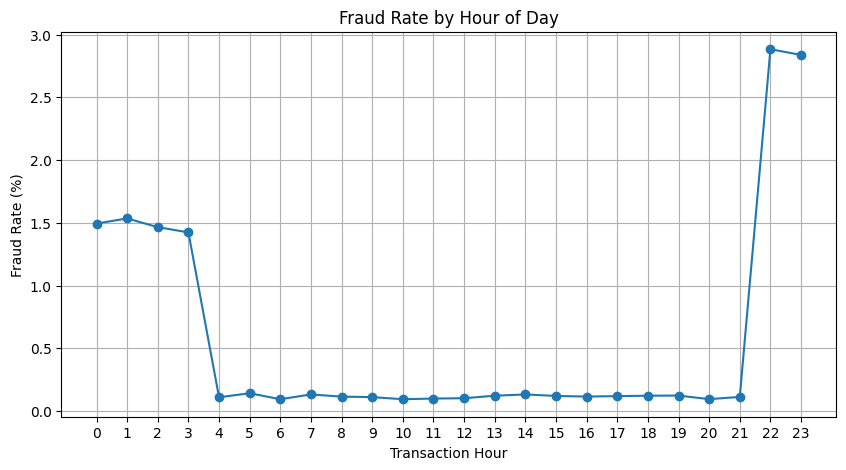

In [26]:
hourly_fraud_rate.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [27]:
print("Train period:")
print(train_df["trans_date_trans_time"].min())
print(train_df["trans_date_trans_time"].max())

print("\nTest period:")
print(test_df["trans_date_trans_time"].min())
print(test_df["trans_date_trans_time"].max())

Train period:
2019-01-01 00:00:18
2020-06-21 12:13:37

Test period:
2020-06-21 12:14:25
2020-12-31 23:59:34


In [28]:
train_df["day_of_week"] = train_df["trans_date_trans_time"].dt.day_name()


In [29]:
day_fraud_rate = (
    train_df.groupby("day_of_week")["is_fraud"]
    .mean()
    .mul(100)
)

day_fraud_rate

day_of_week
Friday       0.708600
Monday       0.464838
Saturday     0.610578
Sunday       0.485276
Thursday     0.684387
Tuesday      0.583547
Wednesday    0.655360
Name: is_fraud, dtype: float64

In [30]:
day_analysis = (
    train_df.groupby("day_of_week")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

day_analysis["fraud_rate"] = day_analysis["mean"] * 100

day_analysis

,count,sum,mean,fraud_rate
day_of_week,,,,
Friday,152272,1079,0.007086,0.708600
Monday,254282,1182,0.004648,0.464838
Saturday,200957,1227,0.006106,0.610578
Sunday,250579,1216,0.004853,0.485276
Thursday,147285,1008,0.006844,0.684387
Tuesday,160227,935,0.005835,0.583547
Wednesday,131073,859,0.006554,0.655360


In [31]:
import numpy as np

lat1 = np.radians(train_df["lat"])
lon1 = np.radians(train_df["long"])
lat2 = np.radians(train_df["merch_lat"])
lon2 = np.radians(train_df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

train_df["distance_km"] = 6371 * c

In [32]:
train_df[["lat", "long", "merch_lat", "merch_long", "distance_km"]].head()

,lat,long,merch_lat,merch_long,distance_km
0,36.0788,-81.1781,36.011293,-82.048315,78.597568
1,48.8878,-118.2105,49.159047,-118.186462,30.212176
2,42.1808,-112.2620,43.150704,-112.154481,108.206083
3,46.2306,-112.1138,47.034331,-112.561071,95.673231
4,38.4207,-79.4629,38.674999,-78.632459,77.556744


In [33]:
distance_analysis = train_df.groupby("is_fraud")["distance_km"].describe()

distance_analysis

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,76.113756,29.119051,0.022255,55.332701,78.233012,98.504498,152.117173
1,7506.0,76.268330,28.752602,0.738769,55.632890,77.931954,98.391090,144.522410


In [34]:
import numpy as np

lat1 = np.radians(train_df["lat"])
lon1 = np.radians(train_df["long"])
lat2 = np.radians(train_df["merch_lat"])
lon2 = np.radians(train_df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

train_df["distance_km"] = 6371 * c

In [35]:
print("distance_km" in train_df.columns)
print(train_df["distance_km"].head())

True
0     78.597568
1     30.212176
2    108.206083
3     95.673231
4     77.556744
Name: distance_km, dtype: float64


In [36]:
import matplotlib.pyplot as plt

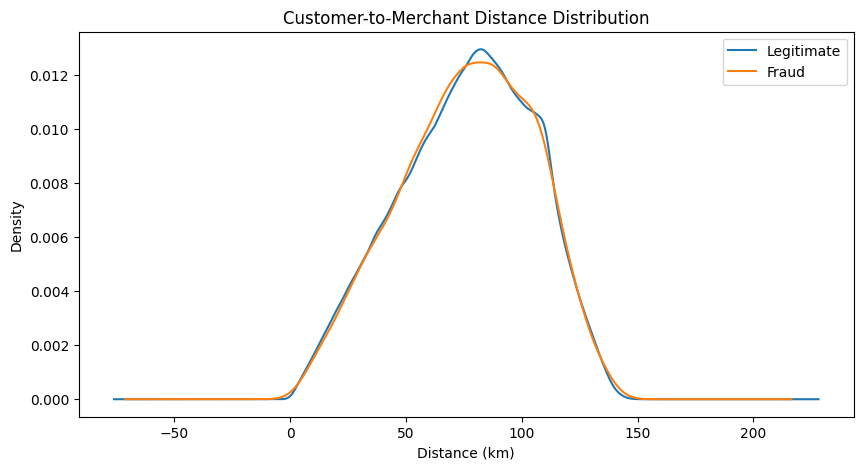

In [37]:
train_df.groupby("is_fraud")["distance_km"].plot(
    kind="kde",
    figsize=(10, 5)
)

plt.xlabel("Distance (km)")
plt.title("Customer-to-Merchant Distance Distribution")
plt.legend(["Legitimate", "Fraud"])
plt.show()

In [38]:
train_df.groupby("is_fraud")["amt"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,67.667110,47.280,1.00,28948.90
1,7506,531.320092,396.505,1.06,1376.04


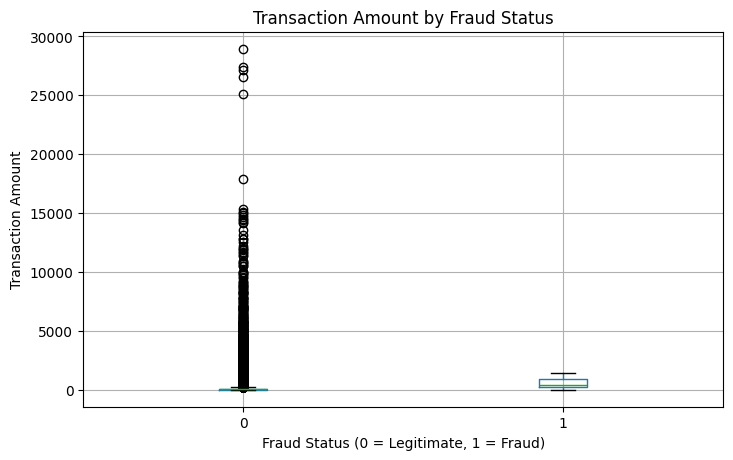

In [39]:
train_df.boxplot(
    column="amt",
    by="is_fraud",
    figsize=(8, 5)
)

plt.title("Transaction Amount by Fraud Status")
plt.suptitle("")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

In [40]:
train_df["amount_range"] = pd.cut(
    train_df["amt"],
    bins=[0, 25, 50, 100, 250, 500, 1000, float("inf")],
    labels=[
        "0-25",
        "25-50",
        "50-100",
        "100-250",
        "250-500",
        "500-1000",
        "1000+"
    ]
)

amount_fraud_rate = (
    train_df.groupby("amount_range", observed=True)["is_fraud"]
    .agg(["count", "sum", "mean"])
)

amount_fraud_rate["fraud_rate"] = amount_fraud_rate["mean"] * 100

amount_fraud_rate

,count,sum,mean,fraud_rate
amount_range,,,,
0-25,463556,1552,0.003348,0.334803
25-50,208743,55,0.000263,0.026348
50-100,389483,45,0.000116,0.011554
100-250,196435,244,0.001242,0.124214
250-500,22827,1962,0.085951,8.595085
500-1000,11695,2699,0.230782,23.078239
1000+,3936,949,0.241108,24.110772


In [41]:
gender_fraud = (
    train_df.groupby("gender")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

gender_fraud["fraud_rate"] = gender_fraud["mean"] * 100

gender_fraud

,count,sum,mean,fraud_rate
gender,,,,
F,709863,3735,0.005262,0.526158
M,586812,3771,0.006426,0.642625


In [42]:
gender_category_fraud = (
    train_df.groupby(["gender", "category"])["is_fraud"]
    .mean()
    .mul(100)
    .unstack()
)

gender_category_fraud

category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
gender,,,,,,,,,,,,,,
F,0.302974,0.239724,0.350916,0.225528,1.148107,0.247547,0.275740,0.302177,1.099919,0.389353,0.293335,1.239722,0.673733,0.327999
M,0.189853,0.081259,0.615338,0.381604,1.703706,0.051680,0.031122,0.097691,1.891638,0.228023,0.163238,2.433188,0.790320,0.245278


In [43]:
card_transaction_count = (
    train_df.groupby("cc_num")
    .size()
    .describe()
)

card_transaction_count

count     983.000000
mean     1319.099695
std       812.235900
min         7.000000
25%       525.000000
50%      1054.000000
75%      2025.000000
max      3123.000000
dtype: float64

In [44]:
merchant_fraud = (
    train_df.groupby("merchant")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

merchant_fraud["fraud_rate"] = merchant_fraud["mean"] * 100

merchant_fraud = merchant_fraud[
    merchant_fraud["count"] >= 100
].sort_values("fraud_rate", ascending=False)

merchant_fraud.head(10)

,count,sum,mean,fraud_rate
merchant,,,,
fraud_Kozey-Boehm,1866,48,0.025723,2.572347
"fraud_Herman, Treutel and Dickens",1300,33,0.025385,2.538462
fraud_Kerluke-Abshire,1838,41,0.022307,2.230686
fraud_Brown PLC,1176,26,0.022109,2.210884
fraud_Goyette Inc,1943,42,0.021616,2.161606
fraud_Terry-Huel,1996,43,0.021543,2.154309
fraud_Jast Ltd,1953,42,0.021505,2.150538
"fraud_Schmeler, Bashirian and Price",1968,41,0.020833,2.083333
fraud_Boyer-Reichert,1908,38,0.019916,1.991614


In [45]:
merchant_summary = train_df.groupby("merchant")["is_fraud"].agg(
    transactions="count",
    fraud_count="sum"
)

print("Unique merchants:", train_df["merchant"].nunique())
print("Merchants with at least one fraud:", (merchant_summary["fraud_count"] > 0).sum())
print("Merchants with no fraud:", (merchant_summary["fraud_count"] == 0).sum())

Unique merchants: 693
Merchants with at least one fraud: 679
Merchants with no fraud: 14


In [46]:
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

In [47]:
train_df["transaction_month"] = train_df["trans_date_trans_time"].dt.month

In [48]:
train_df[["trans_date_trans_time", "transaction_month"]].head()

,trans_date_trans_time,transaction_month
0,2019-01-01 00:00:18,1
1,2019-01-01 00:00:44,1
2,2019-01-01 00:00:51,1
3,2019-01-01 00:01:16,1
4,2019-01-01 00:03:06,1


In [49]:
monthly_fraud_rate = (
    train_df.groupby("transaction_month")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

monthly_fraud_rate["fraud_rate"] = (
    monthly_fraud_rate["mean"] * 100
)

monthly_fraud_rate

,count,sum,mean,fraud_rate
transaction_month,,,,
1,104727,849,0.008107,0.810679
2,97657,853,0.008735,0.873465
3,143789,938,0.006523,0.652345
4,134970,678,0.005023,0.502334
5,146875,935,0.006366,0.636596
6,143811,688,0.004784,0.478406
7,86596,331,0.003822,0.382235
8,87359,382,0.004373,0.437276
9,70652,418,0.005916,0.591632


In [50]:
job_fraud = (
    train_df.groupby("job")["is_fraud"]
    .agg(["count", "sum", "mean"])
)

job_fraud["fraud_rate"] = job_fraud["mean"] * 100

job_fraud = (
    job_fraud[job_fraud["count"] >= 100]
    .sort_values("fraud_rate", ascending=False)
)

job_fraud.head(10)

,count,sum,mean,fraud_rate
job,,,,
Lawyer,540,28,0.051852,5.185185
TEFL teacher,533,22,0.041276,4.127580
Community development worker,536,22,0.041045,4.104478
Clinical cytogeneticist,508,18,0.035433,3.543307
Writer,504,15,0.029762,2.976190
"Geneticist, molecular",545,16,0.029358,2.935780
"Conservator, museum/gallery",514,15,0.029183,2.918288
Magazine journalist,533,14,0.026266,2.626642
Field trials officer,518,13,0.025097,2.509653


In [51]:
numeric_cols = train_df.select_dtypes(include="number")

numeric_cols.corr()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,distance_km,transaction_month
Unnamed: 0,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767,0.001073,-0.000665,0.181956
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,-0.000801,0.003730,-0.000281
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,-0.022811,-0.001085,-0.001748
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.005938,0.006183,0.000852
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,-0.011508,-0.072634,-0.001072
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.002290,0.004058,-0.001213
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,0.020381,0.010901,0.000137
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,0.000756,-0.000633,0.184868
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,-0.011378,-0.072662,-0.001116
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.002325,0.004083,-0.001197


In [52]:
train_df.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'transaction_hour',
 'day_of_week',
 'distance_km',
 'amount_range',
 'transaction_month']

In [53]:
df = train_df.copy()
df.shape

(1296675, 28)

In [54]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["transaction_day"] = df["trans_date_trans_time"].dt.day
df["transaction_month"] = df["trans_date_trans_time"].dt.month
df["transaction_year"] = df["trans_date_trans_time"].dt.year
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek

In [55]:
df["dob"] = pd.to_datetime(df["dob"])

df["customer_age"] = (
    df["trans_date_trans_time"].dt.year
    - df["dob"].dt.year
)

In [56]:
df[["dob", "trans_date_trans_time", "customer_age"]].head()

,dob,trans_date_trans_time,customer_age
0,1988-03-09,2019-01-01 00:00:18,31
1,1978-06-21,2019-01-01 00:00:44,41
2,1962-01-19,2019-01-01 00:00:51,57
3,1967-01-12,2019-01-01 00:01:16,52
4,1986-03-28,2019-01-01 00:03:06,33


In [57]:
df["customer_age"].describe()

count    1.296675e+06
mean     4.602930e+01
std      1.738237e+01
min      1.400000e+01
25%      3.300000e+01
50%      4.400000e+01
75%      5.700000e+01
max      9.600000e+01
Name: customer_age, dtype: float64

In [58]:
card_transaction_count = df["cc_num"].value_counts()

df["card_transaction_count"] = df["cc_num"].map(card_transaction_count)

In [59]:
df[["cc_num", "card_transaction_count", "is_fraud"]].head()

,cc_num,card_transaction_count,is_fraud
0,2703186189652095,2028,0
1,630423337322,3030,0
2,38859492057661,503,0
3,3534093764340240,493,0
4,375534208663984,2017,0


In [60]:
df.groupby("is_fraud")["card_transaction_count"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,1821.834766,740.926305,471.0,1471.0,2001.0,2524.0,3123.0
1,7506.0,1284.673728,816.656759,7.0,524.0,1047.0,2024.0,3123.0


In [61]:
df = df.drop(columns=[
    "Unnamed: 0",
    "trans_num",
    "first",
    "last",
    "street",
    "cc_num"
])

In [62]:
df.shape

(1296675, 26)

In [63]:
df.columns.tolist()

['trans_date_trans_time',
 'merchant',
 'category',
 'amt',
 'gender',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'transaction_hour',
 'day_of_week',
 'distance_km',
 'amount_range',
 'transaction_month',
 'transaction_day',
 'transaction_year',
 'customer_age',
 'card_transaction_count']

In [64]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1296675, 25)
y shape: (1296675,)


In [65]:
X.dtypes

trans_date_trans_time     datetime64[ns]
merchant                          object
category                          object
amt                              float64
gender                            object
city                              object
state                             object
zip                                int64
lat                              float64
long                             float64
city_pop                           int64
job                               object
dob                       datetime64[ns]
unix_time                          int64
merch_lat                        float64
merch_long                       float64
transaction_hour                   int32
day_of_week                        int32
distance_km                      float64
amount_range                    category
transaction_month                  int32
transaction_day                    int32
transaction_year                   int32
customer_age                       int32
card_transaction

In [66]:
X = X.drop(columns=[
    "trans_date_trans_time",
    "dob"
])

print(X.shape)

(1296675, 23)


In [67]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

['merchant', 'category', 'gender', 'city', 'state', 'job']
Number of categorical columns: 6


In [68]:
for col in categorical_cols:
    print(col, ":", X[col].nunique())

merchant : 693
category : 14
gender : 2
city : 894
state : 51
job : 494


In [69]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_encoded = encoder.fit_transform(X[categorical_cols])

print("Encoded shape:", X_encoded.shape)

Encoded shape: (1296675, 2148)


In [70]:
numerical_cols = X.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()

print(numerical_cols)
print("Number of numerical columns:", len(numerical_cols))

['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'transaction_hour', 'day_of_week', 'distance_km', 'transaction_month', 'transaction_day', 'transaction_year', 'customer_age', 'card_transaction_count']
Number of numerical columns: 16


In [71]:
for col in categorical_cols:
    print(col, ":", X[col].nunique())

merchant : 693
category : 14
gender : 2
city : 894
state : 51
job : 494


In [72]:
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


In [73]:
X[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
transaction_hour,1296675.0,1.280486e+01,6.817824e+00,0.000000e+00,7.000000e+00,1.400000e+01,1.900000e+01,2.300000e+01
day_of_week,1296675.0,3.070604e+00,2.198153e+00,0.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00


In [74]:
numerical_cols.remove("zip")

print(numerical_cols)
print("Number of numerical columns:", len(numerical_cols))

['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'transaction_hour', 'day_of_week', 'distance_km', 'transaction_month', 'transaction_day', 'transaction_year', 'customer_age', 'card_transaction_count']
Number of numerical columns: 15


In [75]:
time_cols = [
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_year",
    "day_of_week"
]

for col in time_cols:
    print(col, ":", sorted(X[col].unique()))

transaction_hour : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
transaction_day : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31)]
transaction_month : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
transaction_year : [np.int32(2

In [76]:
import numpy as np

X["hour_sin"] = np.sin(2 * np.pi * X["transaction_hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["transaction_hour"] / 24)

X["day_sin"] = np.sin(2 * np.pi * (X["transaction_day"] - 1) / 31)
X["day_cos"] = np.cos(2 * np.pi * (X["transaction_day"] - 1) / 31)

X["month_sin"] = np.sin(2 * np.pi * (X["transaction_month"] - 1) / 12)
X["month_cos"] = np.cos(2 * np.pi * (X["transaction_month"] - 1) / 12)

X["weekday_sin"] = np.sin(2 * np.pi * X["day_of_week"] / 7)
X["weekday_cos"] = np.cos(2 * np.pi * X["day_of_week"] / 7)

print(X.shape)

(1296675, 31)


In [77]:
time_to_drop = [
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "day_of_week"
]

X = X.drop(columns=time_to_drop)

print("X shape:", X.shape)
print(X.columns.tolist())

X shape: (1296675, 27)
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'amount_range', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [78]:
X = X.drop(columns=["zip"])

print("X shape:", X.shape)
print(X.columns.tolist())

X shape: (1296675, 26)
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'amount_range', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1037340, 26)
X_val: (259335, 26)
y_train: (1037340,)
y_val: (259335,)


In [80]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)

Training categorical shape: (1037340, 2148)
Validation categorical shape: (259335, 2148)


In [81]:
numerical_cols = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "unix_time",
    "merch_lat",
    "merch_long",
    "distance_km",
    "transaction_year",
    "customer_age",
    "card_transaction_count",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos"
]

print("Number of numerical features:", len(numerical_cols))

Number of numerical features: 19


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_val_num = scaler.transform(X_val[numerical_cols])

print("Training numerical shape:", X_train_num.shape)
print("Validation numerical shape:", X_val_num.shape)

Training numerical shape: (1037340, 19)
Validation numerical shape: (259335, 19)


In [83]:
from scipy.sparse import hstack

X_train_processed = hstack([
    X_train_cat,
    X_train_num
])

X_val_processed = hstack([
    X_val_cat,
    X_val_num
])

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed training shape: (1037340, 2167)
Processed validation shape: (259335, 2167)


In [84]:
print("Training fraud rate:")
print(y_train.value_counts(normalize=True).mul(100))

print("\nValidation fraud rate:")
print(y_val.value_counts(normalize=True).mul(100))

Training fraud rate:
is_fraud
0    99.421116
1     0.578884
Name: proportion, dtype: float64

Validation fraud rate:
is_fraud
0    99.421212
1     0.578788
Name: proportion, dtype: float64


In [85]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [86]:
y_val_pred = baseline_model.predict(X_val_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_val_pred))

Predictions generated successfully.
Number of predictions: 259335


In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[233524  24310]
 [   214   1287]]


In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    257834
           1       0.05      0.86      0.09      1501

    accuracy                           0.91    259335
   macro avg       0.52      0.88      0.52    259335
weighted avg       0.99      0.91      0.95    259335



In [89]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_val_proba = baseline_model.predict_proba(X_val_processed)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.954700819568372
PR-AUC: 0.2655338231600137


In [90]:
baseline_results = {
    "Model": "Logistic Regression",
    "Precision": 0.39,
    "Recall": 0.61,
    "F1": 0.47,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Precision': 0.39, 'Recall': 0.61, 'F1': 0.47, 'ROC-AUC': 0.954700819568372, 'PR-AUC': 0.2655338231600137}


In [91]:
import psutil

ram_gb = psutil.virtual_memory().total / (1024 ** 3)
available_gb = psutil.virtual_memory().available / (1024 ** 3)

print(f"Total RAM: {ram_gb:.2f} GB")
print(f"Available RAM: {available_gb:.2f} GB")

Total RAM: 7.68 GB
Available RAM: 1.01 GB


In [92]:
import gc

gc.collect()

available_gb = psutil.virtual_memory().available / (1024 ** 3)

print(f"Available RAM after cleanup: {available_gb:.2f} GB")

Available RAM after cleanup: 0.88 GB


In [93]:
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)

X_train_processed: (1037340, 2167)
X_val_processed: (259335, 2167)


In [94]:
print(type(X_train_processed))
print(type(X_val_processed))

<class 'scipy.sparse._coo.coo_matrix'>
<class 'scipy.sparse._coo.coo_matrix'>


In [95]:
print("X_train_num shape:", X_train_num.shape)
print("X_val_num shape:", X_val_num.shape)

X_train_num shape: (1037340, 19)
X_val_num shape: (259335, 19)


In [96]:
print("Numerical columns:")
print(numerical_cols)
print("Number of columns:", len(numerical_cols))

Numerical columns:
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
Number of columns: 19


In [97]:
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_train_num:", X_train_num.shape)
print("X_val_num:", X_val_num.shape)
print("categorical_cols:", len(categorical_cols))
print("numerical_cols:", len(numerical_cols))   

X_train_processed: (1037340, 2167)
X_val_processed: (259335, 2167)
X_train_num: (1037340, 19)
X_val_num: (259335, 19)
categorical_cols: 6
numerical_cols: 19


In [98]:
categorical_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

numerical_cols = [
    'amt',
    'lat',
    'long',
    'city_pop',
    'unix_time',
    'merch_lat',
    'merch_long',
    'distance_km',
    'transaction_year',
    'customer_age',
    'card_transaction_count',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',
    'weekday_sin',
    'weekday_cos'
]

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 6
Numerical: 19


In [99]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])

print("Training categorical shape:", X_train_cat.shape)
print("Validation categorical shape:", X_val_cat.shape)

Training categorical shape: (1037340, 2148)
Validation categorical shape: (259335, 2148)


In [100]:
print("train_df shape:", train_df.shape)

print("\nMissing engineered columns:")
required_columns = [
    'distance_km',
    'transaction_year',
    'customer_age',
    'card_transaction_count',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',
    'weekday_sin',
    'weekday_cos'
]

print([col for col in required_columns if col not in train_df.columns])

train_df shape: (1296675, 28)

Missing engineered columns:
['transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [101]:
print(X.columns.tolist())

['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'amount_range', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [102]:
print(train_df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'transaction_hour', 'day_of_week', 'distance_km', 'amount_range', 'transaction_month']


In [103]:
#X = X.drop(columns=[
    #"Unnamed: 0",
    #"cc_num",
    #"first",
    #"last",
    #"street",
    #"trans_num",
    #"amount_range"
#])

#print("X shape:", X.shape)
#print(X.columns.tolist())#/

In [104]:
from sklearn.model_selection import train_test_split

y = train_df["is_fraud"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1037340, 26)
X_val: (259335, 26)
y_train: (1037340,)
y_val: (259335,)


In [105]:
print("hello")

hello


In [106]:
X_train_cat = X_train[categorical_cols]
X_val_cat = X_val[categorical_cols]

X_train_num = X_train[numerical_cols]
X_val_num = X_val[numerical_cols]

print("Training categorical:", X_train_cat.shape)
print("Validation categorical:", X_val_cat.shape)

print("Training numerical:", X_train_num.shape)
print("Validation numerical:", X_val_num.shape)

Training categorical: (1037340, 6)
Validation categorical: (259335, 6)
Training numerical: (1037340, 19)
Validation numerical: (259335, 19)


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)

print("Training numerical scaled:", X_train_num_scaled.shape)
print("Validation numerical scaled:", X_val_num_scaled.shape)

Training numerical scaled: (1037340, 19)
Validation numerical scaled: (259335, 19)


In [108]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_val_cat_encoded = encoder.transform(X_val_cat)

print("Training categorical encoded:", X_train_cat_encoded.shape)
print("Validation categorical encoded:", X_val_cat_encoded.shape)

Training categorical encoded: (1037340, 2148)
Validation categorical encoded: (259335, 2148)


In [109]:
from scipy.sparse import hstack

X_train_processed = hstack([
    X_train_num_scaled,
    X_train_cat_encoded
]).tocsr()

X_val_processed = hstack([
    X_val_num_scaled,
    X_val_cat_encoded
]).tocsr()

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed training shape: (1037340, 2167)
Processed validation shape: (259335, 2167)


In [110]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

print("Baseline model retrained successfully.")

Baseline model retrained successfully.


In [111]:
y_val_proba = baseline_model.predict_proba(X_val_processed)[:, 1]

print("Probability predictions generated successfully.")
print("Number of predictions:", len(y_val_proba))

Probability predictions generated successfully.
Number of predictions: 259335


In [112]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)

print("Best threshold:", thresholds[best_idx])
print("Best precision:", precision[best_idx])
print("Best recall:", recall[best_idx])
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.963995139075559
Best precision: 0.3812741312741313
Best recall: 0.5263157894736842
Best F1: 0.4422054295622481


In [113]:
baseline_result = {
    "Model": "Logistic Regression",
    "Threshold": 0.50,
    "Precision": 0.39,
    "Recall": 0.61,
    "F1": 0.47,
    "ROC-AUC": 0.9179990992143606,
    "PR-AUC": 0.3024633889444663
}

print(baseline_result)

{'Model': 'Logistic Regression', 'Threshold': 0.5, 'Precision': 0.39, 'Recall': 0.61, 'F1': 0.47, 'ROC-AUC': 0.9179990992143606, 'PR-AUC': 0.3024633889444663}


In [114]:
print("Current processed features:", X_train_processed.shape[1])
print("Training rows:", X_train_processed.shape[0])
print("Validation rows:", X_val_processed.shape[0])

Current processed features: 2167
Training rows: 1037340
Validation rows: 259335


In [115]:
print("Training matrix type:", type(X_train_processed))
print("Validation matrix type:", type(X_val_processed))

print("Training matrix memory:",
      X_train_processed.data.nbytes / (1024**2), "MB")

print("Validation matrix memory:",
      X_val_processed.data.nbytes / (1024**2), "MB")

Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Validation matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Training matrix memory: 197.85690307617188 MB
Validation matrix memory: 49.46422576904297 MB


In [116]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.7.2


In [117]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=20,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

In [118]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=20,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

sgd_model.fit(X_train_processed, y_train)

print("SGD model trained successfully.")

SGD model trained successfully.


c:\Users\TARUN\fraud-detection-system\.venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [119]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

y_val_sgd_pred = sgd_model.predict(X_val_processed)
y_val_sgd_score = sgd_model.decision_function(X_val_processed)

print("SGD Precision:", precision_score(y_val, y_val_sgd_pred))
print("SGD Recall:", recall_score(y_val, y_val_sgd_pred))
print("SGD F1:", f1_score(y_val, y_val_sgd_pred))
print("SGD ROC-AUC:", roc_auc_score(y_val, y_val_sgd_score))
print("SGD PR-AUC:", average_precision_score(y_val, y_val_sgd_score))

SGD Precision: 0.04877584434375357
SGD Recall: 0.8534310459693538
SGD F1: 0.0922777697738078
SGD ROC-AUC: 0.9570323994206293
SGD PR-AUC: 0.2609628807440529


In [120]:
sgd_result = {
    "Model": "SGD Classifier",
    "Precision": 0.0488,
    "Recall": 0.8534,
    "F1": 0.0923,
    "ROC-AUC": 0.9570,
    "PR-AUC": 0.2610
}

print(sgd_result)

{'Model': 'SGD Classifier', 'Precision': 0.0488, 'Recall': 0.8534, 'F1': 0.0923, 'ROC-AUC': 0.957, 'PR-AUC': 0.261}


In [121]:
import pandas as pd

model_results = pd.DataFrame([
    baseline_result,
    sgd_result
])

print(model_results)

                 Model  Threshold  Precision  Recall      F1   ROC-AUC  \
0  Logistic Regression        0.5     0.3900  0.6100  0.4700  0.917999   
1       SGD Classifier        NaN     0.0488  0.8534  0.0923  0.957000   

     PR-AUC  
0  0.302463  
1  0.261000  


In [122]:
del sgd_model
del y_val_sgd_pred
del y_val_sgd_score

import gc
gc.collect()

print("SGD model and predictions cleared.")

SGD model and predictions cleared.


In [123]:
from sklearn.model_selection import train_test_split

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=300000,
    random_state=42,
    stratify=y_train
)

print("Sample training shape:", X_train_sample.shape)
print("Sample target shape:", y_train_sample.shape)

Sample training shape: (300000, 2167)
Sample target shape: (300000,)


In [124]:
print("Fraud cases:", y_train_sample.sum())
print("Legitimate cases:", (y_train_sample == 0).sum())
print("Fraud rate:", y_train_sample.mean() * 100)

Fraud cases: 1737
Legitimate cases: 298263
Fraud rate: 0.579


In [125]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = baseline_model.predict(X_val_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Confusion Matrix:
[[233486  24348]
 [   214   1287]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    257834
           1       0.05      0.86      0.09      1501

    accuracy                           0.91    259335
   macro avg       0.52      0.88      0.52    259335
weighted avg       0.99      0.91      0.95    259335



In [126]:
print("Model features:", baseline_model.n_features_in_)
print("Processed features:", X_val_processed.shape[1])

Model features: 2167
Processed features: 2167


In [127]:
print("Predicted fraud:", y_val_pred.sum())
print("Actual fraud:", y_val.sum())

Predicted fraud: 25635
Actual fraud: 1501


In [128]:
print(y_train.value_counts())

is_fraud
0    1031335
1       6005
Name: count, dtype: int64


In [129]:
print("Class weights:", baseline_model.class_weight)
print("C:", baseline_model.C)
print("Solver:", baseline_model.solver)

Class weights: balanced
C: 1.0
Solver: lbfgs


In [130]:
print("Minimum probability:", y_val_proba.min())
print("Maximum probability:", y_val_proba.max())
print("Mean probability:", y_val_proba.mean())

Minimum probability: 5.45461277021083e-09
Maximum probability: 1.0
Mean probability: 0.13387203744084794


In [131]:
print("Actual fraud rate:", y_val.mean())
print("Mean predicted probability:", y_val_proba.mean())

Actual fraud rate: 0.005787880540613492
Mean predicted probability: 0.13387203744084794


In [132]:
print("Numerical columns used:")
print(numerical_cols)

print("\nCategorical columns used:")
print(categorical_cols)


Numerical columns used:
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']

Categorical columns used:
['merchant', 'category', 'gender', 'city', 'state', 'job']


In [133]:
print("Scaler fitted features:", scaler.n_features_in_)
print("Current numerical features:", len(numerical_cols))

Scaler fitted features: 19
Current numerical features: 19


In [134]:
print("Encoder features:", encoder.get_feature_names_out().shape[0])
print("Encoded training features:", X_train_cat_encoded.shape[1])

Encoder features: 2148
Encoded training features: 2148


In [135]:
print("Scaled numerical mean:", X_train_num_scaled.mean())
print("Scaled numerical std:", X_train_num_scaled.std())

Scaled numerical mean: -3.268837048699768e-15
Scaled numerical std: 0.9999999999999986


In [136]:
print("Actual fraud rate:", y_val.mean())
print(
    "Predicted fraud rate at 0.5:",
    (y_val_proba >= 0.5).mean()
)

Actual fraud rate: 0.005787880540613492
Predicted fraud rate at 0.5: 0.09884897911967147


In [137]:
print("Model training samples:", baseline_model.n_features_in_)
print("X_train_processed:", X_train_processed.shape)
print("y_train:", y_train.shape)

Model training samples: 2167
X_train_processed: (1037340, 2167)
y_train: (1037340,)


In [138]:
print(X_train_num_scaled[:3])

[[-0.11862583  1.19542948  1.10866998 -0.2936242  -0.37097538  1.22226336
   1.13051258 -1.5261422  -0.63406181 -1.03719168  1.00181956  1.21717057
   1.0193442   1.38591186 -0.05186946 -0.95372771 -1.24597069 -0.47456764
  -1.45171837]
 [-0.36012849 -1.3020398  -0.53892646 -0.28548892 -0.64216804 -1.39419455
  -0.57533837 -0.04643393 -0.63406181  0.1706544   1.00181956 -1.19618599
   0.38571147 -0.82919718  1.1839736   0.50015925 -1.24597069 -1.26492502
  -0.49507868]
 [ 5.67253525  1.93036857 -2.33406539 -0.29357122 -0.30719711  2.07001967
  -2.35212769  0.43971312 -0.63406181 -0.63457632  1.71019641 -0.52408603
  -1.20420102 -0.44556324 -1.333205   -0.95372771 -1.24597069 -0.98284974
   0.69783151]]


In [139]:
from sklearn.linear_model import LogisticRegression

lr_unbalanced = LogisticRegression(
    class_weight=None,
    max_iter=1000,
    random_state=42
)

lr_unbalanced.fit(X_train_processed, y_train)

print("Unbalanced Logistic Regression trained successfully.")


Unbalanced Logistic Regression trained successfully.


In [140]:
y_val_unbalanced_pred = lr_unbalanced.predict(X_val_processed)

print("Precision:", precision_score(y_val, y_val_unbalanced_pred))
print("Recall:", recall_score(y_val, y_val_unbalanced_pred))
print("F1:", f1_score(y_val, y_val_unbalanced_pred))

Precision: 0.6506849315068494
Recall: 0.12658227848101267
F1: 0.21193530395984383


In [141]:
y_val_unbalanced_proba = lr_unbalanced.predict_proba(X_val_processed)[:, 1]

print("Probability predictions generated successfully.")

Probability predictions generated successfully.


In [142]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_unbalanced_proba
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)

print("Best threshold:", thresholds[best_idx])
print("Best precision:", precision[best_idx])
print("Best recall:", recall[best_idx])
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.13332696679514583
Best precision: 0.5240101095197978
Best recall: 0.41439040639573615
Best F1: 0.46279761899830124


In [143]:
y_val_unbalanced_pred_tuned = (
    y_val_unbalanced_proba >= thresholds[best_idx]
).astype(int)

print("Precision:", precision_score(y_val, y_val_unbalanced_pred_tuned))
print("Recall:", recall_score(y_val, y_val_unbalanced_pred_tuned))
print("F1:", f1_score(y_val, y_val_unbalanced_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_val, y_val_unbalanced_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_unbalanced_proba))

Precision: 0.5240101095197978
Recall: 0.41439040639573615
F1: 0.46279761904761907
ROC-AUC: 0.919452577663899
PR-AUC: 0.33538012455257604


In [144]:
tuned_lr_result = {
    "Model": "Logistic Regression (Tuned Threshold)",
    "Threshold": thresholds[best_idx],
    "Precision": precision_score(y_val, y_val_unbalanced_pred_tuned),
    "Recall": recall_score(y_val, y_val_unbalanced_pred_tuned),
    "F1": f1_score(y_val, y_val_unbalanced_pred_tuned),
    "ROC-AUC": roc_auc_score(y_val, y_val_unbalanced_proba),
    "PR-AUC": average_precision_score(y_val, y_val_unbalanced_proba)
}

print(tuned_lr_result)

{'Model': 'Logistic Regression (Tuned Threshold)', 'Threshold': np.float64(0.13332696679514583), 'Precision': 0.5240101095197978, 'Recall': 0.41439040639573615, 'F1': 0.46279761904761907, 'ROC-AUC': 0.919452577663899, 'PR-AUC': 0.33538012455257604}


In [145]:
model_results = pd.DataFrame([
    baseline_result,
    sgd_result,
    tuned_lr_result
])

print(model_results)

                                   Model  Threshold  Precision   Recall  \
0                    Logistic Regression   0.500000    0.39000  0.61000   
1                         SGD Classifier        NaN    0.04880  0.85340   
2  Logistic Regression (Tuned Threshold)   0.133327    0.52401  0.41439   

         F1   ROC-AUC    PR-AUC  
0  0.470000  0.917999  0.302463  
1  0.092300  0.957000  0.261000  
2  0.462798  0.919453  0.335380  


In [146]:
model_results.to_csv("model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [147]:
import os

print("File exists:", os.path.exists("model_comparison.csv"))

File exists: True


In [148]:
print(model_results)

                                   Model  Threshold  Precision   Recall  \
0                    Logistic Regression   0.500000    0.39000  0.61000   
1                         SGD Classifier        NaN    0.04880  0.85340   
2  Logistic Regression (Tuned Threshold)   0.133327    0.52401  0.41439   

         F1   ROC-AUC    PR-AUC  
0  0.470000  0.917999  0.302463  
1  0.092300  0.957000  0.261000  
2  0.462798  0.919453  0.335380  


In [149]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, y_val_unbalanced_pred_tuned))

[[257269    565]
 [   879    622]]


In [150]:
print("Fraud detection rate:", 622 / 1501)

Fraud detection rate: 0.41439040639573615


In [151]:
print("False positive rate:", 565 / (257269 + 565))

False positive rate: 0.002191332407673154


In [152]:
final_result = {
    "Model": "Logistic Regression (Tuned Threshold)",
    "Threshold": thresholds[best_idx],
    "Precision": precision_score(y_val, y_val_unbalanced_pred_tuned),
    "Recall": recall_score(y_val, y_val_unbalanced_pred_tuned),
    "F1": f1_score(y_val, y_val_unbalanced_pred_tuned),
    "ROC-AUC": roc_auc_score(y_val, y_val_unbalanced_proba),
    "PR-AUC": average_precision_score(y_val, y_val_unbalanced_proba)
}

print(final_result)

{'Model': 'Logistic Regression (Tuned Threshold)', 'Threshold': np.float64(0.13332696679514583), 'Precision': 0.5240101095197978, 'Recall': 0.41439040639573615, 'F1': 0.46279761904761907, 'ROC-AUC': 0.919452577663899, 'PR-AUC': 0.33538012455257604}


In [153]:
final_results_df = pd.DataFrame([final_result])

final_results_df.to_csv("final_model_result.csv", index=False)

print("Final model result saved successfully.")

Final model result saved successfully.


In [154]:
import os

print(os.listdir())

['01_eda.ipynb', 'amount_cap_999.txt', 'category_values.pkl', 'confusion_matrix_result.csv', 'encoder.pkl', 'feature_columns.pkl', 'final_model_result.csv', 'final_threshold.txt', 'final_threshold_caplog.txt', 'final_threshold_cleanlog.txt', 'fraud_logistic_caplog_model.pkl', 'fraud_logistic_cleanlog_model.pkl', 'fraud_logistic_model.pkl', 'model_comparison.csv', 'scaler.pkl', 'scaler_caplog.pkl', 'scaler_cleanlog.pkl', 'validation_predictions.csv']


In [155]:
print("Train processed:", X_train_processed.shape)
print("Validation processed:", X_val_processed.shape)
print("Final threshold:", final_result["Threshold"])

Train processed: (1037340, 2167)
Validation processed: (259335, 2167)
Final threshold: 0.13332696679514583


In [156]:
tn, fp, fn, tp = confusion_matrix(
    y_val,
    y_val_unbalanced_pred_tuned
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 257269
FP: 565
FN: 879
TP: 622


In [157]:
accuracy = (tp + tn) / (tp + tn + fp + fn)

print("Accuracy:", accuracy)

Accuracy: 0.9944319123913086


In [158]:
confusion_result = {
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "Accuracy": accuracy
}

print(confusion_result)

{'TN': np.int64(257269), 'FP': np.int64(565), 'FN': np.int64(879), 'TP': np.int64(622), 'Accuracy': np.float64(0.9944319123913086)}


In [159]:
pd.DataFrame([confusion_result]).to_csv(
    "confusion_matrix_result.csv",
    index=False
)

print("Confusion matrix result saved successfully.")

Confusion matrix result saved successfully.


In [160]:
import os

print(os.listdir())

['01_eda.ipynb', 'amount_cap_999.txt', 'category_values.pkl', 'confusion_matrix_result.csv', 'encoder.pkl', 'feature_columns.pkl', 'final_model_result.csv', 'final_threshold.txt', 'final_threshold_caplog.txt', 'final_threshold_cleanlog.txt', 'fraud_logistic_caplog_model.pkl', 'fraud_logistic_cleanlog_model.pkl', 'fraud_logistic_model.pkl', 'model_comparison.csv', 'scaler.pkl', 'scaler_caplog.pkl', 'scaler_cleanlog.pkl', 'validation_predictions.csv']


In [161]:
print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 565
False Negatives: 879


In [162]:
print("False Positive Rate:", fp / (fp + tn))
print("False Negative Rate:", fn / (fn + tp))

False Positive Rate: 0.002191332407673154
False Negative Rate: 0.5856095936042638


In [163]:
threshold = 0.10

y_pred_010 = (y_val_unbalanced_proba >= threshold).astype(int)

print("Precision:", precision_score(y_val, y_pred_010))
print("Recall:", recall_score(y_val, y_pred_010))
print("F1:", f1_score(y_val, y_pred_010))

Precision: 0.4169148302561048
Recall: 0.46635576282478347
F1: 0.44025157232704404


In [164]:
threshold = 0.10

y_pred_010 = (y_val_unbalanced_proba >= threshold).astype(int)

print("Precision:", precision_score(y_val, y_pred_010))
print("Recall:", recall_score(y_val, y_pred_010))
print("F1:", f1_score(y_val, y_pred_010))

Precision: 0.4169148302561048
Recall: 0.46635576282478347
F1: 0.44025157232704404


In [165]:
threshold = 0.20

y_pred_020 = (y_val_unbalanced_proba >= threshold).astype(int)

print("Precision:", precision_score(y_val, y_pred_020))
print("Recall:", recall_score(y_val, y_pred_020))
print("F1:", f1_score(y_val, y_pred_020))

Precision: 0.6156763590391909
Recall: 0.32445036642238506
F1: 0.424956369982548


In [166]:
threshold = 0.15

y_pred_015 = (y_val_unbalanced_proba >= threshold).astype(int)

print("Precision:", precision_score(y_val, y_pred_015))
print("Recall:", recall_score(y_val, y_pred_015))
print("F1:", f1_score(y_val, y_pred_015))

Precision: 0.5559808612440191
Recall: 0.3870752831445703
F1: 0.45640219952867245


In [167]:
threshold = 0.12

y_pred_012 = (y_val_unbalanced_proba >= threshold).astype(int)

print("Precision:", precision_score(y_val, y_pred_012))
print("Recall:", recall_score(y_val, y_pred_012))
print("F1:", f1_score(y_val, y_pred_012))

Precision: 0.478486646884273
Recall: 0.4297135243171219
F1: 0.45279045279045277


In [168]:
final_threshold = thresholds[best_idx]

final_predictions = (
    y_val_unbalanced_proba >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)
print("Final predictions created successfully.")

Final threshold: 0.13332696679514583
Final predictions created successfully.


In [169]:
final_predictions_df = pd.DataFrame({
    "actual": y_val.values,
    "predicted": final_predictions,
    "fraud_probability": y_val_unbalanced_proba
})

final_predictions_df.to_csv(
    "validation_predictions.csv",
    index=False
)

print("Validation predictions saved successfully.")


Validation predictions saved successfully.


In [170]:
print(final_predictions_df.shape)
print(final_predictions_df.head())

(259335, 3)
   actual  predicted  fraud_probability
0       0          0           0.003659
1       0          0           0.000013
2       0          0           0.000923
3       0          0           0.001739
4       0          0           0.004815


In [171]:
print("Actual fraud:", final_predictions_df["actual"].sum())
print("Predicted fraud:", final_predictions_df["predicted"].sum())

Actual fraud: 1501
Predicted fraud: 1187


In [172]:
print(confusion_matrix(
    final_predictions_df["actual"],
    final_predictions_df["predicted"]
))

[[257269    565]
 [   879    622]]


In [173]:
with open("final_threshold.txt", "w") as f:
    f.write(str(final_threshold))

print("Final threshold saved:", final_threshold)

Final threshold saved: 0.13332696679514583


In [174]:
import joblib

joblib.dump(lr_unbalanced, "fraud_logistic_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [175]:
import os

print(os.listdir())

['01_eda.ipynb', 'amount_cap_999.txt', 'category_values.pkl', 'confusion_matrix_result.csv', 'encoder.pkl', 'feature_columns.pkl', 'final_model_result.csv', 'final_threshold.txt', 'final_threshold_caplog.txt', 'final_threshold_cleanlog.txt', 'fraud_logistic_caplog_model.pkl', 'fraud_logistic_cleanlog_model.pkl', 'fraud_logistic_model.pkl', 'model_comparison.csv', 'scaler.pkl', 'scaler_caplog.pkl', 'scaler_cleanlog.pkl', 'validation_predictions.csv']


In [176]:
import joblib

test_model = joblib.load("fraud_logistic_model.pkl")

print("Model loaded successfully.")
print("Model features:", test_model.n_features_in_)


Model loaded successfully.
Model features: 2167


In [177]:
import os

size_mb = os.path.getsize("fraud_logistic_model.pkl") / (1024 * 1024)

print("Model file size:", round(size_mb, 2), "MB")

Model file size: 0.02 MB


In [178]:
with open("final_threshold.txt", "r") as f:
    saved_threshold = float(f.read())

print("Saved threshold:", saved_threshold)

Saved threshold: 0.13332696679514583


In [179]:
import os

for file in os.listdir():
    print(file)

01_eda.ipynb
amount_cap_999.txt
category_values.pkl
confusion_matrix_result.csv
encoder.pkl
feature_columns.pkl
final_model_result.csv
final_threshold.txt
final_threshold_caplog.txt
final_threshold_cleanlog.txt
fraud_logistic_caplog_model.pkl
fraud_logistic_cleanlog_model.pkl
fraud_logistic_model.pkl
model_comparison.csv
scaler.pkl
scaler_caplog.pkl
scaler_cleanlog.pkl
validation_predictions.csv


In [180]:
print("Scaler type:", type(scaler))
print("Encoder type:", type(encoder))

Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Encoder type: <class 'sklearn.preprocessing._encoders.OneHotEncoder'>


In [181]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [182]:
joblib.dump(encoder, "encoder.pkl")

print("Encoder saved successfully.")

Encoder saved successfully.


In [183]:
import os

for file in ["fraud_logistic_model.pkl", "scaler.pkl", "encoder.pkl"]:
    print(file, "→", round(os.path.getsize(file) / (1024 * 1024), 2), "MB")

fraud_logistic_model.pkl → 0.02 MB
scaler.pkl → 0.0 MB
encoder.pkl → 0.04 MB


In [184]:
for col, categories in zip(categorical_cols, encoder.categories_):
    print(col, "→", len(categories), "categories")

merchant → 693 categories
category → 14 categories
gender → 2 categories
city → 894 categories
state → 51 categories
job → 494 categories


In [185]:
print("Scaler feature count:", len(scaler.feature_names_in_))
print("Scaler features:")
print(scaler.feature_names_in_)

Scaler feature count: 19
Scaler features:
['amt' 'lat' 'long' 'city_pop' 'unix_time' 'merch_lat' 'merch_long'
 'distance_km' 'transaction_year' 'customer_age' 'card_transaction_count'
 'hour_sin' 'hour_cos' 'day_sin' 'day_cos' 'month_sin' 'month_cos'
 'weekday_sin' 'weekday_cos']


In [186]:
joblib.dump(
    {
        "numerical_cols": numerical_cols,
        "categorical_cols": categorical_cols
    },
    "feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [187]:
for file in [
    "fraud_logistic_model.pkl",
    "scaler.pkl",
    "encoder.pkl",
    "feature_columns.pkl",
    "final_threshold.txt"
]:
    print(file, "→", os.path.exists(file))

fraud_logistic_model.pkl → True
scaler.pkl → True
encoder.pkl → True
feature_columns.pkl → True
final_threshold.txt → True


In [188]:
model = joblib.load("fraud_logistic_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")
encoder_loaded = joblib.load("encoder.pkl")
features_loaded = joblib.load("feature_columns.pkl")

with open("final_threshold.txt", "r") as f:
    threshold_loaded = float(f.read())

print("All pipeline files loaded successfully.")
print("Threshold:", threshold_loaded)

All pipeline files loaded successfully.
Threshold: 0.13332696679514583


In [189]:
sample = X_val.iloc[[0]].copy()

print("Sample transaction shape:", sample.shape)
print(sample)

Sample transaction shape: (1, 26)
                               merchant  category   amt gender     city state  \
1161537  fraud_Ferry, Lynch and Kautzer  misc_net  6.64      F  Mifflin    PA   

             lat     long  city_pop              job  ...  customer_age  \
1161537  40.5553 -77.4001      1909  Mining engineer  ...            66   

         card_transaction_count  hour_sin  hour_cos   day_sin   day_cos  \
1161537                    2027  0.707107  0.707107 -0.571268  0.820763   

         month_sin     month_cos  weekday_sin  weekday_cos  
1161537        1.0  6.123234e-17     0.974928    -0.222521  

[1 rows x 26 columns]


In [190]:
extra_cols = set(X_val.columns) - set(
    numerical_cols + categorical_cols
)

print("Extra columns:", extra_cols)

Extra columns: {'amount_range'}


In [191]:
sample = sample.drop(columns=["amount_range"])

print("Sample shape after dropping amount_range:", sample.shape)

Sample shape after dropping amount_range: (1, 25)


In [192]:
sample_cat = sample[categorical_cols]
sample_num = sample[numerical_cols]

print("Categorical:", sample_cat.shape)
print("Numerical:", sample_num.shape)

Categorical: (1, 6)
Numerical: (1, 19)


In [193]:
sample_num_scaled = scaler_loaded.transform(sample_num)
sample_cat_encoded = encoder_loaded.transform(sample_cat)

print("Scaled numerical:", sample_num_scaled.shape)
print("Encoded categorical:", sample_cat_encoded.shape)

Scaled numerical: (1, 19)
Encoded categorical: (1, 2148)


In [194]:
from scipy.sparse import hstack

sample_processed = hstack([
    sample_num_scaled,
    sample_cat_encoded
])

print("Processed sample shape:", sample_processed.shape)

Processed sample shape: (1, 2167)


In [195]:
sample_probability = model.predict_proba(sample_processed)[0, 1]

print("Fraud probability:", sample_probability)

Fraud probability: 0.003658745431298271


In [196]:
X_train_num = X_train[numerical_cols]
X_val_num = X_val[numerical_cols]

print("Training numerical shape:", X_train_num.shape)
print("Validation numerical shape:", X_val_num.shape)

Training numerical shape: (1037340, 19)
Validation numerical shape: (259335, 19)


In [197]:
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)

print("Training scaled shape:", X_train_num_scaled.shape)
print("Validation scaled shape:", X_val_num_scaled.shape)

Training scaled shape: (1037340, 19)
Validation scaled shape: (259335, 19)


In [198]:
X_train_cat = X_train[categorical_cols]
X_val_cat = X_val[categorical_cols]

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_val_cat_encoded = encoder.transform(X_val_cat)

print("Training categorical shape:", X_train_cat_encoded.shape)
print("Validation categorical shape:", X_val_cat_encoded.shape)

Training categorical shape: (1037340, 2148)
Validation categorical shape: (259335, 2148)


In [199]:
from scipy.sparse import hstack

X_train_processed = hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_val_processed = hstack([
    X_val_num_scaled,
    X_val_cat_encoded
])

print("Final training shape:", X_train_processed.shape)
print("Final validation shape:", X_val_processed.shape)

Final training shape: (1037340, 2167)
Final validation shape: (259335, 2167)


In [200]:
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

print("\nTraining fraud cases:", y_train.sum())
print("Validation fraud cases:", y_val.sum())

Training target shape: (1037340,)
Validation target shape: (259335,)

Training fraud cases: 6005
Validation fraud cases: 1501


In [201]:
from sklearn.linear_model import LogisticRegression

lr_unbalanced = LogisticRegression(
    class_weight=None,
    max_iter=1000,
    random_state=42
)

lr_unbalanced.fit(X_train_processed, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [202]:
y_val_proba = lr_unbalanced.predict_proba(X_val_processed)[:, 1]

print("Probability shape:", y_val_proba.shape)
print("Minimum probability:", y_val_proba.min())
print("Maximum probability:", y_val_proba.max())

Probability shape: (259335,)
Minimum probability: 1.0243809061156917e-10
Maximum probability: 1.0


In [203]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_idx = np.argmax(f1_scores)

final_threshold = thresholds[best_idx]

print("Best threshold:", final_threshold)
print("Best Precision:", precision[best_idx])
print("Best Recall:", recall[best_idx])
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.13332696679514583
Best Precision: 0.5240101095197978
Best Recall: 0.41439040639573615
Best F1: 0.46279761899830124


In [204]:
final_predictions = (y_val_proba >= final_threshold).astype(int)

print("Predicted fraud cases:", final_predictions.sum())
print("Actual fraud cases:", y_val.sum())

Predicted fraud cases: 1187
Actual fraud cases: 1501


In [205]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, final_predictions)

print(cm)

[[257269    565]
 [   879    622]]


In [206]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

print("Precision:", precision_score(y_val, final_predictions))
print("Recall:", recall_score(y_val, final_predictions))
print("F1 Score:", f1_score(y_val, final_predictions))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

Precision: 0.5240101095197978
Recall: 0.41439040639573615
F1 Score: 0.46279761904761907
ROC-AUC: 0.919452577663899
PR-AUC: 0.33538012455257604


In [207]:
import joblib

joblib.dump(lr_unbalanced, "fraud_logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Model and preprocessing objects saved successfully.")

Model and preprocessing objects saved successfully.


In [208]:
with open("final_threshold.txt", "w") as f:
    f.write(str(final_threshold))

print("Final threshold saved:", final_threshold)

Final threshold saved: 0.13332696679514583


In [209]:
joblib.dump(
    {
        "numerical_cols": numerical_cols,
        "categorical_cols": categorical_cols
    },
    "feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [210]:
import os

files = [
    "fraud_logistic_model.pkl",
    "scaler.pkl",
    "encoder.pkl",
    "feature_columns.pkl",
    "final_threshold.txt"
]

for file in files:
    print(file, "->", os.path.exists(file))

fraud_logistic_model.pkl -> True
scaler.pkl -> True
encoder.pkl -> True
feature_columns.pkl -> True
final_threshold.txt -> True


In [211]:
model = joblib.load("fraud_logistic_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")
encoder_loaded = joblib.load("encoder.pkl")
features_loaded = joblib.load("feature_columns.pkl")

with open("final_threshold.txt", "r") as f:
    threshold_loaded = float(f.read())

print("Model features:", model.n_features_in_)
print("Threshold:", threshold_loaded)
print("Numerical features:", len(features_loaded["numerical_cols"]))
print("Categorical features:", len(features_loaded["categorical_cols"]))

Model features: 2167
Threshold: 0.13332696679514583
Numerical features: 19
Categorical features: 6


In [212]:
sample = X_val.iloc[[0]].copy()

# Remove unused feature
if "amount_range" in sample.columns:
    sample = sample.drop(columns=["amount_range"])

sample_num = sample[numerical_cols]
sample_cat = sample[categorical_cols]

sample_num_scaled = scaler_loaded.transform(sample_num)
sample_cat_encoded = encoder_loaded.transform(sample_cat)

sample_processed = hstack([
    sample_num_scaled,
    sample_cat_encoded
])

sample_probability = model.predict_proba(sample_processed)[0, 1]
sample_prediction = int(sample_probability >= threshold_loaded)

print("Fraud probability:", sample_probability)
print("Prediction:", "Fraud" if sample_prediction == 1 else "Legitimate")

Fraud probability: 0.003658745431298271
Prediction: Legitimate


In [213]:
def predict_fraud(sample):

    if "amount_range" in sample.columns:
        sample = sample.drop(columns=["amount_range"])

    sample_num = sample[numerical_cols]
    sample_cat = sample[categorical_cols]

    sample_num_scaled = scaler_loaded.transform(sample_num)
    sample_cat_encoded = encoder_loaded.transform(sample_cat)

    sample_processed = hstack([
        sample_num_scaled,
        sample_cat_encoded
    ])

    probability = model.predict_proba(sample_processed)[0, 1]
    prediction = int(probability >= threshold_loaded)

    return probability, prediction

In [214]:
probability, prediction = predict_fraud(X_val.iloc[[0]])

print("Fraud probability:", probability)
print("Prediction:", "Fraud" if prediction == 1 else "Legitimate")

Fraud probability: 0.003658745431298271
Prediction: Legitimate


In [215]:
sample_input = X_val.iloc[[0]].copy()

print(sample_input.T)

                                               1161537
merchant                fraud_Ferry, Lynch and Kautzer
category                                      misc_net
amt                                               6.64
gender                                               F
city                                           Mifflin
state                                               PA
lat                                            40.5553
long                                          -77.4001
city_pop                                          1909
job                                    Mining engineer
unix_time                                   1367207861
merch_lat                                    41.405953
merch_long                                  -77.922023
distance_km                                 104.241872
amount_range                                      0-25
transaction_year                                  2020
customer_age                                        66
card_trans

In [216]:
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']

Categorical columns:
['merchant', 'category', 'gender', 'city', 'state', 'job']


In [217]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(X_train[col].unique()[:10])


merchant:
['fraud_Stokes, Christiansen and Sipes' 'fraud_Effertz LLC'
 'fraud_Kris-Padberg' 'fraud_Ratke and Sons' 'fraud_Upton PLC'
 'fraud_Schaefer Ltd' 'fraud_Williamson LLC' 'fraud_Bogisich-Weimann'
 'fraud_Dickinson Ltd' 'fraud_Strosin-Cruickshank']

category:
['grocery_net' 'entertainment' 'shopping_pos' 'health_fitness' 'kids_pets'
 'misc_pos' 'personal_care' 'grocery_pos' 'gas_transport' 'food_dining']

gender:
['F' 'M']

city:
['Hannawa Falls' 'Meridian' 'Conway' 'Vinton' 'Owensville' 'Saint Louis'
 'Mc Veytown' 'Schaefferstown' 'East Andover' 'Mayersville']

state:
['NY' 'TX' 'WA' 'CA' 'MO' 'PA' 'ME' 'MS' 'MI' 'NJ']

job:
['Chief Executive Officer' 'Phytotherapist'
 'Research officer, political party' 'Education administrator'
 'Naval architect' 'Occupational hygienist' 'Nutritional therapist'
 'Gaffer' 'Animal nutritionist' 'Technical brewer']


In [218]:
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

merchant: 693 unique values
category: 14 unique values
gender: 2 unique values
city: 894 unique values
state: 51 unique values
job: 494 unique values


In [219]:
joblib.dump(
    {
        "merchant": list(encoder.categories_[0]),
        "category": list(encoder.categories_[1]),
        "gender": list(encoder.categories_[2]),
        "city": list(encoder.categories_[3]),
        "state": list(encoder.categories_[4]),
        "job": list(encoder.categories_[5])
    },
    "category_values.pkl"
)

print("Category values saved successfully.")

Category values saved successfully.


In [220]:
category_values = joblib.load("category_values.pkl")

for col, values in category_values.items():
    print(col, "->", len(values))

merchant -> 693
category -> 14
gender -> 2
city -> 894
state -> 51
job -> 494


In [221]:
import os

print("Project files:")

for file in os.listdir("."):
    print(file)

Project files:
01_eda.ipynb
amount_cap_999.txt
category_values.pkl
confusion_matrix_result.csv
encoder.pkl
feature_columns.pkl
final_model_result.csv
final_threshold.txt
final_threshold_caplog.txt
final_threshold_cleanlog.txt
fraud_logistic_caplog_model.pkl
fraud_logistic_cleanlog_model.pkl
fraud_logistic_model.pkl
model_comparison.csv
scaler.pkl
scaler_caplog.pkl
scaler_cleanlog.pkl
validation_predictions.csv


In [222]:
import joblib

model = joblib.load("fraud_logistic_model.pkl")

In [223]:
model = joblib.load("fraud_logistic_model.pkl")

In [224]:
amt_index = numerical_cols.index("amt")
print("amt coefficient:", model.coef_[0][amt_index])

amt coefficient: 0.45178001178860727


In [225]:
coef_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Coefficient": model.coef_[0][:len(numerical_cols)]
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
12,hour_cos,1.471215
8,transaction_year,0.482375
0,amt,0.451780
2,long,0.186507
1,lat,0.107647
16,month_cos,0.058556
3,city_pop,0.032323
17,weekday_sin,0.024869
7,distance_km,0.004831
9,customer_age,-0.007002


In [226]:
print(X_train["amt"].describe())

count    1.037340e+06
mean     7.034117e+01
std      1.570584e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.750000e+01
75%      8.305000e+01
max      2.739012e+04
Name: amt, dtype: float64


In [227]:
print(
    train_df.groupby("is_fraud")["amt"].describe()
)

              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


In [228]:
print("Legitimate transactions > 5000:",
      ((train_df["is_fraud"] == 0) & (train_df["amt"] > 5000)).sum())

print("Fraud transactions > 5000:",
      ((train_df["is_fraud"] == 1) & (train_df["amt"] > 5000)).sum())

Legitimate transactions > 5000: 136
Fraud transactions > 5000: 0


In [229]:
high_legit = train_df[
    (train_df["is_fraud"] == 0) &
    (train_df["amt"] > 5000)
]

print(high_legit[["amt", "category", "gender", "city", "state"]].head(10))

             amt      category gender               city state
12084    5444.24  shopping_pos      M             Hudson    NY
17743   11872.21        travel      F  Center Tuftonboro    NH
25944    6337.25        travel      F           Metairie    LA
37315   10776.59        travel      M        San Antonio    TX
42665    5234.79        travel      M             Vinton    CA
48934    5027.60  shopping_pos      M              Omaha    NE
59564   12788.07        travel      M      West Harrison    NY
67097    5816.67        travel      M          Haw River    NC
105732  11629.34        travel      F         Providence    RI
109741   5579.69        travel      M         Titusville    FL


In [230]:
sample_legit = train_df.loc[12084]

print(sample_legit)

Unnamed: 0                                          12084
trans_date_trans_time                 2019-01-07 23:50:36
cc_num                                   3567697931646329
merchant                                fraud_Pouros-Haag
category                                     shopping_pos
amt                                               5444.24
first                                                John
last                                              Stevens
gender                                                  M
street                                   428 Morgan River
city                                               Hudson
state                                                  NY
zip                                                 12534
lat                                                42.247
long                                             -73.7552
city_pop                                            17867
job                                 Travel agency manager
dob           

In [231]:
sample = train_df.loc[[12084]].copy()

print(sample["is_fraud"])

12084    0
Name: is_fraud, dtype: int64


In [232]:
sample = train_df.loc[[12084]].copy()

print(sample["is_fraud"])

12084    0
Name: is_fraud, dtype: int64


In [233]:
sample = sample.drop(columns=["is_fraud"])

In [234]:
sample["transaction_datetime"] = pd.to_datetime(sample["trans_date_trans_time"])

sample["transaction_year"] = sample["transaction_datetime"].dt.year
hour = sample["transaction_datetime"].dt.hour
day = sample["transaction_datetime"].dt.day
month = sample["transaction_datetime"].dt.month
weekday = sample["transaction_datetime"].dt.weekday

In [235]:
sample["hour_sin"] = np.sin(2 * np.pi * hour / 24)
sample["hour_cos"] = np.cos(2 * np.pi * hour / 24)

sample["day_sin"] = np.sin(2 * np.pi * day / 31)
sample["day_cos"] = np.cos(2 * np.pi * day / 31)

sample["month_sin"] = np.sin(2 * np.pi * month / 12)
sample["month_cos"] = np.cos(2 * np.pi * month / 12)

sample["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
sample["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

In [236]:
print(sample["distance_km"])

12084    73.364198
Name: distance_km, dtype: float64


In [237]:
sample["dob"] = pd.to_datetime(sample["dob"])
sample["customer_age"] = (
    sample["transaction_datetime"].dt.year - sample["dob"].dt.year
)

In [238]:
print(sample["customer_age"])

12084    21
Name: customer_age, dtype: int32


In [239]:
sample["card_transaction_count"] = train_df.groupby("cc_num")["cc_num"].transform("count").loc[sample.index]

In [240]:
print(sample["card_transaction_count"])

12084    2521
Name: card_transaction_count, dtype: int64


In [241]:
input_data = sample[numerical_cols + categorical_cols].copy()

In [242]:
print(input_data.shape)
print(input_data.columns.tolist())

(1, 25)
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'merchant', 'category', 'gender', 'city', 'state', 'job']


In [243]:
import joblib

scaler_loaded = joblib.load("scaler.pkl")

In [244]:
scaler_loaded = joblib.load("scaler.pkl")

In [245]:
input_num = input_data[numerical_cols]
input_num_scaled = scaler_loaded.transform(input_num)

print(input_num_scaled.shape)

(1, 19)


In [246]:
input_cat = input_data[categorical_cols]
input_cat_encoded = encoder.transform(input_cat)

print(input_cat_encoded.shape)

(1, 2148)


In [247]:
from scipy.sparse import hstack

input_processed = hstack([
    input_num_scaled,
    input_cat_encoded
])

print(input_processed.shape)

(1, 2167)


In [248]:
probability = model.predict_proba(input_processed)[0, 1]

print(f"Fraud Probability: {probability:.2%}")

Fraud Probability: 99.99%


In [249]:
coef = model.coef_[0]

contributions = input_processed.toarray()[0] * coef

top_indices = np.argsort(np.abs(contributions))[::-1][:15]

for idx in top_indices:
    print(idx, contributions[idx])

0 15.458080502837134
727 -2.1983915932888536
12 2.0378856409781445
10 -0.9701872984845216
4 0.8036745201383066
724 0.5181988052071341
503 -0.4188547279799298
8 -0.30585548572258275
1092 0.25110717232706536
2 0.2232838731436752
18 -0.1809156703698009
11 0.09330484105808802
15 -0.08151108139068039
6 -0.07872207202123395
1 0.07860996548160197


In [250]:
print("Original amount:", input_data["amt"].iloc[0])
print("Scaled amount:", input_num_scaled[0, 0])
print("Amount coefficient:", model.coef_[0][0])
print("Amount contribution:", contributions[0])

Original amount: 5444.24
Scaled amount: 34.21594603452739
Amount coefficient: 0.45178001178860727
Amount contribution: 15.458080502837134


In [251]:
print(train_df[train_df["is_fraud"] == 0]["amt"].describe())

count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64


In [252]:
high_legit = train_df[
    (train_df["is_fraud"] == 0) &
    (train_df["amt"] > 5000)
]

print("Legitimate > 5000:", len(high_legit))
print("Highest legitimate amount:", high_legit["amt"].max())

Legitimate > 5000: 136
Highest legitimate amount: 28948.9


In [253]:
print(X_train.shape)
print(X_val.shape)

(1037340, 26)
(259335, 26)


In [254]:
print(X_train.columns.tolist())

['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'amount_range', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [255]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()

X_train_log["amt"] = np.log1p(X_train_log["amt"])
X_val_log["amt"] = np.log1p(X_val_log["amt"])

In [256]:
from sklearn.preprocessing import StandardScaler

scaler_log = StandardScaler()

X_train_num_log = scaler_log.fit_transform(X_train_log[numerical_cols])
X_val_num_log = scaler_log.transform(X_val_log[numerical_cols])

print(X_train_num_log.shape)
print(X_val_num_log.shape)

(1037340, 19)
(259335, 19)


In [257]:
import os
print(os.getcwd())

c:\Users\TARUN\fraud-detection-system\notebooks


In [258]:
encoder_loaded = joblib.load("encoder.pkl")

X_train_cat_log = encoder_loaded.transform(X_train_log[categorical_cols])
X_val_cat_log = encoder_loaded.transform(X_val_log[categorical_cols])

print(X_train_cat_log.shape)
print(X_val_cat_log.shape)

(1037340, 2148)
(259335, 2148)


In [259]:
from scipy.sparse import hstack

X_train_log_processed = hstack([
    X_train_num_log,
    X_train_cat_log
])

X_val_log_processed = hstack([
    X_val_num_log,
    X_val_cat_log
])

print(X_train_log_processed.shape)
print(X_val_log_processed.shape)

(1037340, 2167)
(259335, 2167)


In [260]:
from sklearn.linear_model import LogisticRegression

lr_log = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_log.fit(X_train_log_processed, y_train)

print("Model training completed.")

Model training completed.


In [261]:
y_val_prob_log = lr_log.predict_proba(X_val_log_processed)[:, 1]

print(y_val_prob_log[:10])

[1.73494892e-04 5.29022090e-05 5.59078945e-03 2.49076718e-03
 1.54920630e-03 1.42185166e-05 3.58626247e-04 9.24684169e-04
 2.42544917e-02 5.96356348e-06]


In [262]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_log = roc_auc_score(y_val, y_val_prob_log)
pr_auc_log = average_precision_score(y_val, y_val_prob_log)

print("ROC-AUC:", roc_auc_log)
print("PR-AUC:", pr_auc_log)

ROC-AUC: 0.9022356192520401
PR-AUC: 0.4790222993290996


In [263]:
from sklearn.metrics import precision_recall_curve

precision_log, recall_log, thresholds_log = precision_recall_curve(
    y_val,
    y_val_prob_log
)

f1_scores_log = (
    2 * precision_log[:-1] * recall_log[:-1]
    / (precision_log[:-1] + recall_log[:-1] + 1e-10)
)

best_idx_log = f1_scores_log.argmax()

best_threshold_log = thresholds_log[best_idx_log]
best_precision_log = precision_log[best_idx_log]
best_recall_log = recall_log[best_idx_log]
best_f1_log = f1_scores_log[best_idx_log]

print("Best Threshold:", best_threshold_log)
print("Precision:", best_precision_log)
print("Recall:", best_recall_log)
print("F1:", best_f1_log)

Best Threshold: 0.1789409316797712
Precision: 0.5880551301684533
Recall: 0.5116588940706196
F1: 0.5472034199716165


In [264]:
sample_log = input_data.copy()

sample_log["amt"] = np.log1p(sample_log["amt"])

sample_num_log = scaler_log.transform(sample_log[numerical_cols])
sample_cat_log = encoder_loaded.transform(sample_log[categorical_cols])

sample_processed_log = hstack([
    sample_num_log,
    sample_cat_log
])

probability_log = lr_log.predict_proba(sample_processed_log)[0, 1]

prediction_log = int(probability_log >= best_threshold_log)

print("Fraud Probability:", probability_log)
print("Prediction:", "Fraud" if prediction_log == 1 else "Legitimate")

Fraud Probability: 0.73385764625411
Prediction: Fraud


In [265]:
coef_log = lr_log.coef_[0]

contributions_log = (
    sample_processed_log.toarray()[0] * coef_log
)

top_indices_log = np.argsort(
    np.abs(contributions_log)
)[::-1][:15]

for idx in top_indices_log:
    print(idx, contributions_log[idx])

0 7.271236956968338
727 -2.4531976002876625
12 1.7798842017083913
10 -0.741826985029618
4 0.27967237651262783
18 -0.1712611809585035
2153 0.1544369567981405
16 0.14209403762091122
1656 -0.13268295250665707
1092 0.12042136272289801
503 -0.11415117210315343
11 0.10968448679890251
1 0.09475586972285803
724 0.08082323388856874
5 -0.079277389940417


In [266]:
print("Original amount:", input_data["amt"].iloc[0])
print("Log amount:", sample_log["amt"].iloc[0])
print("Scaled log amount:", sample_num_log[0, 0])
print("Amount coefficient:", coef_log[0])
print("Amount contribution:", contributions_log[0])

Original amount: 5444.24
Log amount: 8.60249711153068
Scaled log amount: 3.9322600040592386
Amount coefficient: 1.8491241549293034
Amount contribution: 7.271236956968338


In [267]:
print(pd.to_datetime(1325980236, unit="s"))

2012-01-07 23:50:36


In [268]:
time_check = pd.to_datetime(train_df["unix_time"], unit="s")
actual_time = pd.to_datetime(train_df["trans_date_trans_time"])

year_difference = actual_time.dt.year - time_check.dt.year

print(year_difference.value_counts().sort_index())

7    1296675
Name: count, dtype: int64


In [269]:
print("Unix time contribution:", contributions_log[4])
print("Unix time coefficient:", coef_log[4])
print("Scaled unix time:", sample_num_log[0, 4])

Unix time contribution: 0.27967237651262783
Unix time coefficient: -0.15435411688084044
Scaled unix time: -1.8118880284128192


In [270]:
print("Transaction hour:", sample["transaction_datetime"].dt.hour.iloc[0])
print("hour_sin:", sample["hour_sin"].iloc[0])
print("hour_cos:", sample["hour_cos"].iloc[0])
print("hour_cos contribution:", contributions_log[12])

Transaction hour: 23
hour_sin: -0.25881904510252157
hour_cos: 0.9659258262890681
hour_cos contribution: 1.7798842017083913


In [271]:
hour_fraud_rate = (
    train_df.groupby("transaction_hour")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

print(hour_fraud_rate)

transaction_hour
22    0.028829
23    0.028374
1     0.015349
0     0.014940
2     0.014652
3     0.014239
5     0.001423
7     0.001327
14    0.001325
19    0.001236
18    0.001226
13    0.001225
15    0.001208
17    0.001192
16    0.001156
8     0.001153
21    0.001129
9     0.001114
4     0.001099
12    0.001027
11    0.000998
20    0.000952
10    0.000946
6     0.000946
Name: is_fraud, dtype: float64


In [272]:
high_value_legit = train_df[
    (train_df["is_fraud"] == 0) &
    (train_df["amt"] > 5000)
]

print("Legitimate > 5000:", len(high_value_legit))
print(high_value_legit["amt"].describe())

Legitimate > 5000: 136
count      136.000000
mean      8885.827721
std       4576.361163
min       5014.530000
25%       5812.875000
50%       7379.685000
75%      10116.815000
max      28948.900000
Name: amt, dtype: float64


In [273]:
high_value_legit = train_df[
    (train_df["is_fraud"] == 0) &
    (train_df["amt"] > 5000)
].copy()

print(high_value_legit[["amt", "transaction_hour"]].head())
print("Count:", len(high_value_legit))

            amt  transaction_hour
12084   5444.24                23
17743  11872.21                16
25944   6337.25                19
37315  10776.59                15
42665   5234.79                12
Count: 136


In [274]:
high_value_engineered = pd.concat([
    X_train,
    X_val
]).loc[high_value_legit.index].copy()

print(high_value_engineered.shape)

(136, 26)


In [275]:
high_value_input = high_value_engineered.copy()

# Log-transform amount
high_value_input["amt"] = np.log1p(high_value_input["amt"])

# Scale numerical features
high_value_num = scaler_log.transform(
    high_value_input[numerical_cols]
)

# Encode categorical features
high_value_cat = encoder_loaded.transform(
    high_value_input[categorical_cols]
)

# Combine numerical + categorical features
high_value_processed = hstack([
    high_value_num,
    high_value_cat
])

# Predict fraud probability
high_value_prob = lr_log.predict_proba(
    high_value_processed
)[:, 1]

# Use the F1-selected threshold
high_value_pred = (
    high_value_prob >= best_threshold_log
).astype(int)

print("Legitimate transactions:", len(high_value_legit))
print("Predicted as fraud:", high_value_pred.sum())
print("Predicted as legitimate:", (high_value_pred == 0).sum())
print("False-positive rate:", high_value_pred.mean())

Legitimate transactions: 136
Predicted as fraud: 33
Predicted as legitimate: 103
False-positive rate: 0.2426470588235294


In [276]:
high_value_results = high_value_legit[[
    "amt",
    "transaction_hour",
    "category",
    "gender",
    "city",
    "state"
]].copy()

high_value_results["fraud_probability"] = high_value_prob
high_value_results["prediction"] = high_value_pred

high_value_results.sort_values(
    "fraud_probability",
    ascending=False
).head(20)

,amt,transaction_hour,category,gender,city,state,fraud_probability,prediction
541787,8059.02,22,shopping_net,M,Indianapolis,IN,0.955632,1
533846,6993.63,20,shopping_net,F,Hurley,SD,0.937672,1
311491,9555.26,22,shopping_net,M,Ballwin,MO,0.934478,1
683125,5886.30,21,shopping_net,M,Arlington,VA,0.924864,1
1036902,7747.73,0,shopping_pos,M,Andrews,NC,0.904639,1
615816,5758.98,21,shopping_pos,M,Grant,AL,0.871106,1
728925,9754.72,20,shopping_pos,M,Norman Park,GA,0.857710,1
772600,7508.46,17,shopping_net,F,Scotia,SC,0.775164,1
606211,26544.12,22,travel,M,Cross,SC,0.770145,1
12084,5444.24,23,shopping_pos,M,Hudson,NY,0.732447,1


In [277]:
fp_high_value = high_value_results[
    high_value_results["prediction"] == 1
]

print(
    fp_high_value["category"].value_counts()
)

print("\nAverage amount:")
print(fp_high_value["amt"].mean())

print("\nAverage transaction hour:")
print(fp_high_value["transaction_hour"].mean())

category
shopping_pos    12
shopping_net    12
travel           9
Name: count, dtype: int64

Average amount:
8477.179393939394

Average transaction hour:
18.484848484848484


In [278]:
print("Fraud amount statistics:")
print(
    train_df[train_df["is_fraud"] == 1]["amt"].describe()
)

print("\nLegitimate amount > $5,000:")
print(
    train_df[
        (train_df["is_fraud"] == 0) &
        (train_df["amt"] > 5000)
    ]["amt"].describe()
)

Fraud amount statistics:
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64

Legitimate amount > $5,000:
count      136.000000
mean      8885.827721
std       4576.361163
min       5014.530000
25%       5812.875000
50%       7379.685000
75%      10116.815000
max      28948.900000
Name: amt, dtype: float64


In [279]:
# Identify high-value legitimate transactions in validation only
high_value_val = X_val[
    (y_val == 0) &
    (X_val["amt"] > 5000)
].copy()

print("High-value legitimate transactions in validation:", len(high_value_val))
print(high_value_val["amt"].describe())

High-value legitimate transactions in validation: 30
count       30.000000
mean      9920.042667
std       6054.932090
min       5014.530000
25%       5582.605000
50%       7373.665000
75%      12514.797500
max      28948.900000
Name: amt, dtype: float64


In [280]:
high_value_val_log = high_value_val.copy()

# Apply the same transformation used by the log model
high_value_val_log["amt"] = np.log1p(
    high_value_val_log["amt"]
)

# Scale numerical features
high_value_val_num = scaler_log.transform(
    high_value_val_log[numerical_cols]
)

# Encode categorical features
high_value_val_cat = encoder_loaded.transform(
    high_value_val_log[categorical_cols]
)

# Combine
high_value_val_processed = hstack([
    high_value_val_num,
    high_value_val_cat
])

# Predict probabilities
high_value_val_prob = lr_log.predict_proba(
    high_value_val_processed
)[:, 1]

# Classify using log-model threshold
high_value_val_pred = (
    high_value_val_prob >= best_threshold_log
).astype(int)

print("High-value legitimate validation transactions:", len(high_value_val))
print("Predicted as fraud:", high_value_val_pred.sum())
print("Predicted as legitimate:", (high_value_val_pred == 0).sum())
print("False-positive rate:", high_value_val_pred.mean())

High-value legitimate validation transactions: 30
Predicted as fraud: 7
Predicted as legitimate: 23
False-positive rate: 0.23333333333333334


In [281]:
print("Log-model amount coefficient:", lr_log.coef_[0][0])

amount_scaled = high_value_val_num[:, 0]

print("Scaled log-amount statistics:")
print("Min:", amount_scaled.min())
print("Median:", np.median(amount_scaled))
print("Max:", amount_scaled.max())

Log-model amount coefficient: 1.8491241549293034
Scaled log-amount statistics:
Min: 3.868496650553229
Median: 4.167083355871335
Max: 5.228292325142962


In [282]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_pred_log = (
    y_val_prob_log >= best_threshold_log
).astype(int)

print("Log Model - Overall Validation")
print("Precision:", precision_score(y_val, y_val_pred_log))
print("Recall:", recall_score(y_val, y_val_pred_log))
print("F1:", f1_score(y_val, y_val_pred_log))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_log))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_log))

Log Model - Overall Validation
Precision: 0.5880551301684533
Recall: 0.5116588940706196
F1: 0.5472034200213751
ROC-AUC: 0.9022356192520401
PR-AUC: 0.4790222993290996


In [283]:
amount_cap = X_train["amt"].quantile(0.99)

print("99th percentile amount:", amount_cap)

99th percentile amount: 548.6260999999998


In [284]:
amount_cap_999 = X_train["amt"].quantile(0.999)

print("99.9th percentile amount:", amount_cap_999)

99.9th percentile amount: 1511.3432200000016


In [285]:
scaler_caplog = StandardScaler()

X_train_num_caplog = scaler_caplog.fit_transform(
    X_train_caplog[numerical_cols]
)

X_val_num_caplog = scaler_caplog.transform(
    X_val_caplog[numerical_cols]
)

X_train_cat_caplog = encoder_loaded.transform(
    X_train_caplog[categorical_cols]
)

X_val_cat_caplog = encoder_loaded.transform(
    X_val_caplog[categorical_cols]
)

X_train_caplog_processed = hstack([
    X_train_num_caplog,
    X_train_cat_caplog
])

X_val_caplog_processed = hstack([
    X_val_num_caplog,
    X_val_cat_caplog
])

print("Train:", X_train_caplog_processed.shape)
print("Validation:", X_val_caplog_processed.shape)

NameError: name 'X_train_caplog' is not defined

In [ ]:
lr_caplog = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_caplog.fit(
    X_train_caplog_processed,
    y_train
)

print("Model training completed.")

Model training completed.


In [ ]:
y_val_prob_caplog = lr_caplog.predict_proba(
    X_val_caplog_processed
)[:, 1]

roc_auc_caplog = roc_auc_score(y_val, y_val_prob_caplog)
pr_auc_caplog = average_precision_score(y_val, y_val_prob_caplog)

print("ROC-AUC:", roc_auc_caplog)
print("PR-AUC:", pr_auc_caplog)

ROC-AUC: 0.9043220884203382
PR-AUC: 0.49906485561139297


In [ ]:
precision_caplog, recall_caplog, thresholds_caplog = precision_recall_curve(
    y_val,
    y_val_prob_caplog
)

f1_scores_caplog = (
    2 * precision_caplog[:-1] * recall_caplog[:-1]
    / (precision_caplog[:-1] + recall_caplog[:-1] + 1e-10)
)

best_idx_caplog = f1_scores_caplog.argmax()

best_threshold_caplog = thresholds_caplog[best_idx_caplog]
best_precision_caplog = precision_caplog[best_idx_caplog]
best_recall_caplog = recall_caplog[best_idx_caplog]
best_f1_caplog = f1_scores_caplog[best_idx_caplog]

print("Best Threshold:", best_threshold_caplog)
print("Precision:", best_precision_caplog)
print("Recall:", best_recall_caplog)
print("F1:", best_f1_caplog)

Best Threshold: 0.16831567654204685
Precision: 0.5760869565217391
Recall: 0.5296469020652899
F1: 0.5518917042194392


In [ ]:
high_value_val_caplog = X_val[
    (y_val == 0) & (X_val["amt"] > 5000)
].copy()

high_value_val_caplog["amt"] = np.minimum(
    high_value_val_caplog["amt"],
    amount_cap_999
)

high_value_val_caplog["amt"] = np.log1p(
    high_value_val_caplog["amt"]
)

high_value_num_caplog = scaler_caplog.transform(
    high_value_val_caplog[numerical_cols]
)

high_value_cat_caplog = encoder_loaded.transform(
    high_value_val_caplog[categorical_cols]
)

high_value_processed_caplog = hstack([
    high_value_num_caplog,
    high_value_cat_caplog
])

high_value_prob_caplog = lr_caplog.predict_proba(
    high_value_processed_caplog
)[:, 1]

high_value_pred_caplog = (
    high_value_prob_caplog >= best_threshold_caplog
).astype(int)

print("High-value legitimate transactions:", len(high_value_pred_caplog))
print("Predicted as fraud:", high_value_pred_caplog.sum())
print("Predicted as legitimate:", (high_value_pred_caplog == 0).sum())
print(
    "False Positive Rate:",
    high_value_pred_caplog.mean()
)

High-value legitimate transactions: 30
Predicted as fraud: 4
Predicted as legitimate: 26
False Positive Rate: 0.13333333333333333


In [ ]:
sample_caplog = input_data.copy()

sample_caplog["amt"] = np.minimum(
    sample_caplog["amt"],
    amount_cap_999
)

sample_caplog["amt"] = np.log1p(
    sample_caplog["amt"]
)

sample_num_caplog = scaler_caplog.transform(
    sample_caplog[numerical_cols]
)

sample_cat_caplog = encoder_loaded.transform(
    sample_caplog[categorical_cols]
)

sample_processed_caplog = hstack([
    sample_num_caplog,
    sample_cat_caplog
])

probability_caplog = lr_caplog.predict_proba(
    sample_processed_caplog
)[0, 1]

prediction_caplog = int(
    probability_caplog >= best_threshold_caplog
)

print("Fraud Probability:", probability_caplog)
print("Prediction:", "Fraud" if prediction_caplog else "Legitimate")

Fraud Probability: 0.36924273224007825
Prediction: Fraud


In [ ]:
print(type(features_loaded))
print(features_loaded)

<class 'dict'>
{'numerical_cols': ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'], 'categorical_cols': ['merchant', 'category', 'gender', 'city', 'state', 'job']}


In [ ]:
feature_names = (
    features_loaded["numerical_cols"]
    + list(encoder_loaded.get_feature_names_out(
        features_loaded["categorical_cols"]
    ))
)

print("Total feature names:", len(feature_names))
print(feature_names[:19])

Total feature names: 2167
['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']


In [ ]:
for idx in top_indices_caplog:
    print(
        idx,
        feature_names[idx],
        contributions_caplog[idx]
    )

0 amt 6.315373460345308
727 gender_M -2.4508480435957885
12 hour_cos 1.860603791124892
10 card_transaction_count -0.835769908544038
4 unix_time 0.5920977611797276
724 category_shopping_pos -0.42202921875500604
2153 job_Travel agency manager 0.29939797800623325
1092 city_Hudson 0.23652998100057887
503 merchant_fraud_Pouros-Haag -0.22706773356031346
8 transaction_year -0.20850790531194935


In [ ]:
from sklearn.metrics import confusion_matrix

y_val_pred_caplog = (
    y_val_prob_caplog >= best_threshold_caplog
).astype(int)

cm_caplog = confusion_matrix(
    y_val,
    y_val_pred_caplog
)

print(cm_caplog)

[[257249    585]
 [   706    795]]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_caplog = accuracy_score(
    y_val,
    y_val_pred_caplog
)

fpr_caplog = cm_caplog[0, 1] / (
    cm_caplog[0, 0] + cm_caplog[0, 1]
)

fnr_caplog = cm_caplog[1, 0] / (
    cm_caplog[1, 0] + cm_caplog[1, 1]
)

print("Accuracy:", accuracy_caplog)
print("FPR:", fpr_caplog)
print("FNR:", fnr_caplog)
print("Precision:", best_precision_caplog)
print("Recall:", best_recall_caplog)
print("F1:", best_f1_caplog)
print("ROC-AUC:", roc_auc_caplog)
print("PR-AUC:", pr_auc_caplog)

Accuracy: 0.9950218828927835
FPR: 0.0022689016964403453
FNR: 0.4703530979347102
Precision: 0.5760869565217391
Recall: 0.5296469020652899
F1: 0.5518917042194392
ROC-AUC: 0.9043220884203382
PR-AUC: 0.49906485561139297


In [ ]:
import joblib

joblib.dump(lr_caplog, "fraud_logistic_caplog_model.pkl")
joblib.dump(scaler_caplog, "scaler_caplog.pkl")

with open("final_threshold_caplog.txt", "w") as f:
    f.write(str(best_threshold_caplog))

print("Capped + log model artifacts saved.")

Capped + log model artifacts saved.


In [ ]:
import joblib

model_caplog_loaded = joblib.load("fraud_logistic_caplog_model.pkl")
scaler_caplog_loaded = joblib.load("scaler_caplog.pkl")

with open("final_threshold_caplog.txt", "r") as f:
    threshold_caplog_loaded = float(f.read())

print("Model features:", model_caplog_loaded.n_features_in_)
print("Threshold:", threshold_caplog_loaded)

Model features: 2167
Threshold: 0.16831567654204685


In [ ]:
def predict_fraud_caplog(sample):
    if "amount_range" in sample.columns:
        sample = sample.drop(columns=["amount_range"])

    sample = sample.copy()

    # Apply the same amount transformation used during training
    sample["amt"] = np.minimum(
        sample["amt"],
        amount_cap_999
    )

    sample["amt"] = np.log1p(sample["amt"])

    # Numerical preprocessing
    sample_num = sample[numerical_cols]

    sample_num_scaled = scaler_caplog_loaded.transform(
        sample_num
    )

    # Categorical preprocessing
    sample_cat = sample[categorical_cols]

    sample_cat_encoded = encoder_loaded.transform(
        sample_cat
    )

    # Combine features
    sample_processed = hstack([
        sample_num_scaled,
        sample_cat_encoded
    ])

    # Prediction
    probability = model_caplog_loaded.predict_proba(
        sample_processed
    )[0, 1]

    prediction = int(
        probability >= threshold_caplog_loaded
    )

    return probability, prediction

In [ ]:
with open("amount_cap_999.txt", "w") as f:
    f.write(str(amount_cap_999))

print("Amount cap:", amount_cap_999)

Amount cap: 1511.3432200000016


In [ ]:
probability_final, prediction_final = predict_fraud_caplog(input_data)

print("Fraud Probability:", probability_final)
print(
    "Prediction:",
    "Fraud" if prediction_final else "Legitimate"
)

Fraud Probability: 0.36924273224007825
Prediction: Fraud


In [ ]:
import os

for file in [
    "fraud_logistic_caplog_model.pkl",
    "scaler_caplog.pkl",
    "encoder.pkl",
    "final_threshold_caplog.txt",
    "amount_cap_999.txt"
]:
    print(file, os.path.exists(file))

fraud_logistic_caplog_model.pkl True
scaler_caplog.pkl True
encoder.pkl True
final_threshold_caplog.txt True
amount_cap_999.txt True


In [ ]:
print(model)


LogisticRegression(max_iter=1000, random_state=42)


In [ ]:
print("Current model:", model)
print("Expected features:", model.n_features_in_)

Current model: LogisticRegression(max_iter=1000, random_state=42)
Expected features: 2167


In [ ]:
print(numerical_cols)
print(categorical_cols)

['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
['merchant', 'category', 'gender', 'city', 'state', 'job']


In [ ]:
import pandas as pd
import numpy as np

X_sample_raw = pd.DataFrame([{
    "amt": 10000,
    "lat": 40.0,
    "long": -74.0,
    "city_pop": 50000,
    "unix_time": 1577836800,
    "merch_lat": 40.05,
    "merch_long": -74.05,
    "distance_km": 7.0,
    "transaction_year": 2020,
    "customer_age": 35,
    "card_transaction_count": 10,
    "hour_sin": 0.0,
    "hour_cos": 1.0,
    "day_sin": 0.0,
    "day_cos": 1.0,
    "month_sin": 0.0,
    "month_cos": 1.0,
    "weekday_sin": 0.0,
    "weekday_cos": 1.0,
    "merchant": "fraud_Pouros-Haag",
    "category": "shopping_pos",
    "gender": "M",
    "city": "Hudson",
    "state": "NY",
    "job": "Travel agency manager"
}])

print(X_sample_raw.shape)

(1, 25)


In [ ]:
# Apply the same preprocessing used by the final capped + log model

X_sample_num = X_sample_raw[numerical_cols].copy()

# 1. Cap amount at the training 99.9th percentile
X_sample_num["amt"] = X_sample_num["amt"].clip(upper=amount_cap_999)

# 2. Apply log transformation
X_sample_num["amt"] = np.log1p(X_sample_num["amt"])

# 3. Scale numerical features
X_sample_scaled = scaler_caplog.transform(X_sample_num)

# 4. Encode categorical features
X_sample_encoded = encoder.transform(
    X_sample_raw[categorical_cols]
)

# 5. Combine numerical + categorical features
X_sample = hstack([
    X_sample_scaled,
    X_sample_encoded
])

print("Shape:", X_sample.shape)
print("Raw probability:", model.predict_proba(X_sample)[0][1])

Shape: (1, 2167)
Raw probability: 0.00022386389037242846


In [ ]:
import numpy as np

In [ ]:
X_sample_raw = {
    "amt": 10000,
    "lat": 40.0,
    "long": -74.0,
    "city_pop": 50000,
    "unix_time": 1577836800,
    "merch_lat": 40.05,
    "merch_long": -74.05,
    "distance_km": 7.0,
    "transaction_year": 2020,
    "customer_age": 35,
    "card_transaction_count": 10,
    "hour_sin": 0.0,
    "hour_cos": 1.0,
    "day_sin": 0.0,
    "day_cos": 1.0,
    "month_sin": 0.0,
    "month_cos": 1.0,
    "weekday_sin": 0.0,
    "weekday_cos": 1.0,
    "merchant": "fraud_Pouros-Haag",
    "category": "shopping_pos",
    "gender": "M",
    "city": "Hudson",
    "state": "NY",
    "job": "Travel agency manager"
}

print(type(X_sample_raw))
print(len(X_sample_raw))

<class 'dict'>
25


In [ ]:
for amount in [100, 500, 1000, 1500, 2000, 3000, 5000, 10000, 50000, 100000]:

    sample = X_sample_raw.copy()
    sample["amt"] = amount

    X_sample = pd.DataFrame([sample])

    X_num = X_sample[numerical_cols].copy()
    X_cat = X_sample[categorical_cols]

    X_num["amt"] = X_num["amt"].clip(
        upper=amount_cap_999
    )

    X_num["amt"] = X_num["amt"].map(
        np.log1p
    )

    X_num_scaled = scaler_caplog.transform(X_num)
    X_cat_encoded = encoder.transform(X_cat)

    X_processed = hstack([
        X_num_scaled,
        X_cat_encoded
    ])

    probability = lr_caplog.predict_proba(
        X_processed
    )[0, 1]

    print(f"₹{amount:<8} → {probability:.6%}")

₹100      → 0.040952%
₹500      → 0.587762%
₹1000     → 1.839678%
₹1500     → 3.551211%
₹2000     → 3.594444%
₹3000     → 3.594444%
₹5000     → 3.594444%
₹10000    → 3.594444%
₹50000    → 3.594444%
₹100000   → 3.594444%


In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Original Logistic Regression",
        "ROC-AUC": 0.9194525777,
        "PR-AUC": 0.3353801246,
        "Precision": 0.5240101095,
        "Recall": 0.4143904064,
        "F1": 0.4627976190,
        "FPR": 0.2191
    },
    {
        "Model": "Log(amount) Logistic Regression",
        "ROC-AUC": 0.9022356193,
        "PR-AUC": 0.4790222993,
        "Precision": 0.5880551302,
        "Recall": 0.5116588941,
        "F1": 0.5472034200,
        "FPR": None
    },
    {
        "Model": "Capped + Log(amount) Logistic Regression",
        "ROC-AUC": 0.9043220884,
        "PR-AUC": 0.4990648556,
        "Precision": 0.5760869565,
        "Recall": 0.5296469021,
        "F1": 0.5518917042,
        "FPR": 0.2269
    }
])

comparison.round(4)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,FPR
0,Original Logistic Regression,0.9195,0.3354,0.5240,0.4144,0.4628,0.2191
1,Log(amount) Logistic Regression,0.9022,0.4790,0.5881,0.5117,0.5472,NaN
2,Capped + Log(amount) Logistic Regression,0.9043,0.4991,0.5761,0.5296,0.5519,0.2269


In [ ]:
# Create copies
X_train_loghigh = X_train.copy()
X_val_loghigh = X_val.copy()

# Log-transform amount
X_train_loghigh["amt"] = np.log1p(X_train_loghigh["amt"])
X_val_loghigh["amt"] = np.log1p(X_val_loghigh["amt"])

# Add a separate indicator for unusually high transactions
high_amount_threshold = X_train["amt"].quantile(0.99)

X_train_loghigh["high_amount"] = (
    X_train["amt"] > high_amount_threshold
).astype(int)

X_val_loghigh["high_amount"] = (
    X_val["amt"] > high_amount_threshold
).astype(int)

print("High amount threshold:", high_amount_threshold)
print("Training shape:", X_train_loghigh.shape)
print("Validation shape:", X_val_loghigh.shape)

High amount threshold: 548.6260999999998
Training shape: (1037340, 27)
Validation shape: (259335, 27)


In [ ]:
scaler_loghigh = StandardScaler()

X_train_num = X_train_loghigh[numerical_cols + ["high_amount"]]
X_val_num = X_val_loghigh[numerical_cols + ["high_amount"]]

X_train_cat = X_train_loghigh[categorical_cols]
X_val_cat = X_val_loghigh[categorical_cols]

X_train_num_scaled = scaler_loghigh.fit_transform(X_train_num)
X_val_num_scaled = scaler_loghigh.transform(X_val_num)

X_train_cat_encoded = encoder.transform(X_train_cat)
X_val_cat_encoded = encoder.transform(X_val_cat)

X_train_loghigh_processed = hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_val_loghigh_processed = hstack([
    X_val_num_scaled,
    X_val_cat_encoded
])

print("Training processed shape:", X_train_loghigh_processed.shape)
print("Validation processed shape:", X_val_loghigh_processed.shape)

Training processed shape: (1037340, 2168)
Validation processed shape: (259335, 2168)


In [ ]:
lr_loghigh = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_loghigh.fit(
    X_train_loghigh_processed,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

# Validation probabilities
y_val_prob_loghigh = lr_loghigh.predict_proba(
    X_val_loghigh_processed
)[:, 1]

# ROC-AUC and PR-AUC
roc_auc_loghigh = roc_auc_score(
    y_val, y_val_prob_loghigh
)

pr_auc_loghigh = average_precision_score(
    y_val, y_val_prob_loghigh
)

# Find F1-optimal threshold
precision, recall, thresholds = precision_recall_curve(
    y_val, y_val_prob_loghigh
)

f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

best_idx = np.argmax(f1_scores)

threshold_loghigh = thresholds[best_idx]

# Predictions using optimal threshold
y_val_pred_loghigh = (
    y_val_prob_loghigh >= threshold_loghigh
).astype(int)

precision_loghigh = precision_score(
    y_val, y_val_pred_loghigh
)

recall_loghigh = recall_score(
    y_val, y_val_pred_loghigh
)

f1_loghigh = f1_score(
    y_val, y_val_pred_loghigh
)

print("ROC-AUC :", roc_auc_loghigh)
print("PR-AUC  :", pr_auc_loghigh)
print("Threshold:", threshold_loghigh)
print("Precision:", precision_loghigh)
print("Recall   :", recall_loghigh)
print("F1       :", f1_loghigh)

ROC-AUC : 0.9332955381581807
PR-AUC  : 0.469901205853857
Threshold: 0.24245871908180713
Precision: 0.6184701492537313
Recall   : 0.4417055296469021
F1       : 0.5153517294986397


In [ ]:
for amount in [100, 500, 1000, 1500, 2000, 3000, 5000, 10000, 50000, 100000]:

    sample = X_sample_raw.copy()
    sample["amt"] = amount

    X_sample = pd.DataFrame([sample])

    # Log amount
    X_sample["amt"] = np.log1p(X_sample["amt"])

    # High amount indicator
    X_sample["high_amount"] = (
        amount > high_amount_threshold
    ).astype(int)

    X_num = X_sample[numerical_cols + ["high_amount"]]
    X_cat = X_sample[categorical_cols]

    X_num_scaled = scaler_loghigh.transform(X_num)
    X_cat_encoded = encoder.transform(X_cat)

    X_processed = hstack([
        X_num_scaled,
        X_cat_encoded
    ])

    probability = lr_loghigh.predict_proba(
        X_processed
    )[0, 1]

    print(f"₹{amount:<8} → {probability:.6%}")

₹100      → 0.002834%
₹500      → 0.005995%
₹1000     → 0.697858%
₹1500     → 0.842240%
₹2000     → 0.962315%
₹3000     → 1.160861%
₹5000     → 1.469490%
₹10000    → 2.020781%
₹50000    → 4.194771%
₹100000   → 5.709458%


In [ ]:
# Create copies
X_train_finaltest = X_train.copy()
X_val_finaltest = X_val.copy()

# Original amount preserved
X_train_finaltest["amt_original"] = X_train["amt"]
X_val_finaltest["amt_original"] = X_val["amt"]

# Log amount
X_train_finaltest["amt"] = np.log1p(X_train["amt"])
X_val_finaltest["amt"] = np.log1p(X_val["amt"])

# High amount indicator
X_train_finaltest["high_amount"] = (
    X_train["amt"] > high_amount_threshold
).astype(int)

X_val_finaltest["high_amount"] = (
    X_val["amt"] > high_amount_threshold
).astype(int)

print("Training shape:", X_train_finaltest.shape)
print("Validation shape:", X_val_finaltest.shape)

Training shape: (1037340, 28)
Validation shape: (259335, 28)


In [ ]:
high_value_val = X_val[
    X_val["amt"] > 5000
].copy()

print("High-value validation transactions:", len(high_value_val))

High-value validation transactions: 30


In [ ]:
from scipy.sparse import csr_matrix

# Convert COO → CSR so we can select rows
X_val_loghigh_csr = csr_matrix(X_val_loghigh_processed)

# Find rows corresponding to high-value transactions
high_value_mask = X_val_loghigh.index.isin(high_value_indices)

X_high_processed = X_val_loghigh_csr[high_value_mask]

# Actual labels
y_high = y_val.loc[high_value_indices]

# Model probabilities
high_probs = lr_loghigh.predict_proba(
    X_high_processed
)[:, 1]

# Predictions using F1-optimal threshold
high_preds = (
    high_probs >= threshold_loghigh
).astype(int)

print("Total high-value transactions:", len(y_high))
print("Actual fraud:", y_high.sum())
print("Actual legitimate:", (y_high == 0).sum())
print("Predicted fraud:", high_preds.sum())
print("Predicted legitimate:", (high_preds == 0).sum())

Total high-value transactions: 30
Actual fraud: 0
Actual legitimate: 30
Predicted fraud: 10
Predicted legitimate: 20


In [ ]:
# Numerical columns for the combo model
numerical_cols_combo = numerical_cols + ["amt_capped", "high_amount"]

# Preprocess
X_train_combo_num = scaler_log.transform(
    X_train_combo[numerical_cols_combo[:-2]]
)

X_val_combo_num = scaler_log.transform(
    X_val_combo[numerical_cols_combo[:-2]]
)

# Scale the two new numerical features separately
scaler_extra = StandardScaler()

X_train_extra = scaler_extra.fit_transform(
    X_train_combo[["amt_capped", "high_amount"]]
)

X_val_extra = scaler_extra.transform(
    X_val_combo[["amt_capped", "high_amount"]]
)

# Encode categorical features
X_train_combo_cat = encoder.transform(
    X_train_combo[categorical_cols]
)

X_val_combo_cat = encoder.transform(
    X_val_combo[categorical_cols]
)

# Combine everything
X_train_combo_processed = hstack([
    X_train_combo_num,
    X_train_extra,
    X_train_combo_cat
]).tocsr()

X_val_combo_processed = hstack([
    X_val_combo_num,
    X_val_extra,
    X_val_combo_cat
]).tocsr()

print("Training processed shape:", X_train_combo_processed.shape)
print("Validation processed shape:", X_val_combo_processed.shape)

Training processed shape: (1037340, 2169)
Validation processed shape: (259335, 2169)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_combo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_combo.fit(
    X_train_combo_processed,
    y_train
)

print("Combo model trained successfully.")

Combo model trained successfully.


In [ ]:
y_val_combo_proba = lr_combo.predict_proba(
    X_val_combo_processed
)[:, 1]

print("Validation probabilities generated.")
print("Minimum:", y_val_combo_proba.min())
print("Maximum:", y_val_combo_proba.max())

Validation probabilities generated.
Minimum: 2.674924510759924e-08
Maximum: 0.9854142773525012


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_combo = roc_auc_score(
    y_val,
    y_val_combo_proba
)

pr_auc_combo = average_precision_score(
    y_val,
    y_val_combo_proba
)

print("ROC-AUC:", roc_auc_combo)
print("PR-AUC:", pr_auc_combo)

ROC-AUC: 0.9353850124258403
PR-AUC: 0.44621755235305555


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_combo_proba
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)
best_threshold_combo = thresholds[best_idx]

print("Best threshold:", best_threshold_combo)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

Best threshold: 0.19102816373889656
Precision: 0.5830564784053156
Recall: 0.46768820786142573
F1: 0.5190388169561481


In [ ]:
test_amounts = [100, 500, 1000, 1500, 2000, 3000, 5000, 10000, 50000, 100000]

for amount in test_amounts:
    X_test_amount = X_train.iloc[[0]].copy()
    X_test_amount["amt"] = amount

    X_test_amount["amt_capped"] = min(amount, amount_cap_999)
    X_test_amount["high_amount"] = int(amount > high_amount_threshold)

    X_test_num = scaler_log.transform(
        X_test_amount[numerical_cols]
    )

    X_test_extra = scaler_extra.transform(
        X_test_amount[["amt_capped", "high_amount"]]
    )

    X_test_cat = encoder.transform(
        X_test_amount[categorical_cols]
    )

    X_test_processed = hstack([
        X_test_num,
        X_test_extra,
        X_test_cat
    ]).tocsr()

    probability = lr_combo.predict_proba(
        X_test_processed
    )[0, 1]

    print(f"₹{amount:,} → {probability:.6%}")

₹100 → 6.224890%
₹500 → 99.993741%
₹1,000 → 100.000000%
₹1,500 → 100.000000%
₹2,000 → 100.000000%
₹3,000 → 100.000000%
₹5,000 → 100.000000%
₹10,000 → 100.000000%
₹50,000 → 100.000000%
₹100,000 → 100.000000%


In [ ]:
# Create a piecewise/log amount feature
X_train_piece = X_train.copy()
X_val_piece = X_val.copy()

# Log transformation preserves differences between large amounts
X_train_piece["amt_log"] = np.log1p(X_train["amt"])
X_val_piece["amt_log"] = np.log1p(X_val["amt"])

# Keep the original amount only up to a moderate cap
amount_cap_piece = X_train["amt"].quantile(0.995)

X_train_piece["amt_capped"] = X_train["amt"].clip(upper=amount_cap_piece)
X_val_piece["amt_capped"] = X_val["amt"].clip(upper=amount_cap_piece)

print("Amount cap:", amount_cap_piece)
print("Training shape:", X_train_piece.shape)
print("Validation shape:", X_val_piece.shape)

Amount cap: 846.8991500000016
Training shape: (1037340, 28)
Validation shape: (259335, 28)


In [ ]:
# Create a piecewise/log amount feature
X_train_piece = X_train.copy()
X_val_piece = X_val.copy()

# Log transformation preserves differences between large amounts
X_train_piece["amt_log"] = np.log1p(X_train["amt"])
X_val_piece["amt_log"] = np.log1p(X_val["amt"])

# Keep the original amount only up to a moderate cap
amount_cap_piece = X_train["amt"].quantile(0.995)

X_train_piece["amt_capped"] = X_train["amt"].clip(upper=amount_cap_piece)
X_val_piece["amt_capped"] = X_val["amt"].clip(upper=amount_cap_piece)

print("Amount cap:", amount_cap_piece)
print("Training shape:", X_train_piece.shape)
print("Validation shape:", X_val_piece.shape)

Amount cap: 846.8991500000016
Training shape: (1037340, 28)
Validation shape: (259335, 28)


In [ ]:
# Numerical columns for the piecewise model
numerical_cols_piece = numerical_cols + ["amt_log", "amt_capped"]

# Scale original numerical features
X_train_piece_base = scaler_log.transform(
    X_train_piece[numerical_cols]
)

X_val_piece_base = scaler_log.transform(
    X_val_piece[numerical_cols]
)

# Scale the two new amount features
scaler_piece_extra = StandardScaler()

X_train_piece_extra = scaler_piece_extra.fit_transform(
    X_train_piece[["amt_log", "amt_capped"]]
)

X_val_piece_extra = scaler_piece_extra.transform(
    X_val_piece[["amt_log", "amt_capped"]]
)

# Encode categorical features
X_train_piece_cat = encoder.transform(
    X_train_piece[categorical_cols]
)

X_val_piece_cat = encoder.transform(
    X_val_piece[categorical_cols]
)

# Combine
X_train_piece_processed = hstack([
    X_train_piece_base,
    X_train_piece_extra,
    X_train_piece_cat
]).tocsr()

X_val_piece_processed = hstack([
    X_val_piece_base,
    X_val_piece_extra,
    X_val_piece_cat
]).tocsr()

print("Training processed shape:", X_train_piece_processed.shape)
print("Validation processed shape:", X_val_piece_processed.shape)

Training processed shape: (1037340, 2169)
Validation processed shape: (259335, 2169)


In [ ]:
lr_piece = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_piece.fit(
    X_train_piece_processed,
    y_train
)

print("Piecewise + Log model trained successfully.")

Piecewise + Log model trained successfully.


In [ ]:
y_val_piece_proba = lr_piece.predict_proba(
    X_val_piece_processed
)[:, 1]

roc_auc_piece = roc_auc_score(
    y_val,
    y_val_piece_proba
)

pr_auc_piece = average_precision_score(
    y_val,
    y_val_piece_proba
)

print("ROC-AUC:", roc_auc_piece)
print("PR-AUC:", pr_auc_piece)

ROC-AUC: 0.9420872496155991
PR-AUC: 0.6263666843123168


In [ ]:
precision_piece, recall_piece, thresholds_piece = precision_recall_curve(
    y_val,
    y_val_piece_proba
)

f1_piece = (
    2 * precision_piece[:-1] * recall_piece[:-1]
    / (precision_piece[:-1] + recall_piece[:-1] + 1e-10)
)

best_idx_piece = np.argmax(f1_piece)

best_threshold_piece = thresholds_piece[best_idx_piece]

print("Best threshold:", best_threshold_piece)
print("Precision:", precision_piece[best_idx_piece])
print("Recall:", recall_piece[best_idx_piece])
print("F1:", f1_piece[best_idx_piece])

Best threshold: 0.21216696245965103
Precision: 0.7042971595047341
Recall: 0.6442371752165224
F1: 0.6729297146334674


In [ ]:
test_amounts = [100, 500, 1000, 1500, 2000, 3000, 5000, 10000, 50000, 100000]

for amount in test_amounts:
    X_test_amount = X_train.iloc[[0]].copy()

    X_test_amount["amt"] = amount
    X_test_amount["amt_log"] = np.log1p(amount)
    X_test_amount["amt_capped"] = min(amount, amount_cap_piece)

    X_test_base = scaler_log.transform(
        X_test_amount[numerical_cols]
    )

    X_test_extra = scaler_piece_extra.transform(
        X_test_amount[["amt_log", "amt_capped"]]
    )

    X_test_cat = encoder.transform(
        X_test_amount[categorical_cols]
    )

    X_test_processed = hstack([
        X_test_base,
        X_test_extra,
        X_test_cat
    ]).tocsr()

    probability = lr_piece.predict_proba(
        X_test_processed
    )[0, 1]

    print(f"₹{amount:,} → {probability:.6%}")

₹100 → 0.263865%
₹500 → 73.696081%
₹1,000 → 99.914390%
₹1,500 → 95.837004%
₹2,000 → 35.014780%
₹3,000 → 0.037766%
₹5,000 → 0.000000%
₹10,000 → 0.000000%
₹50,000 → 0.000000%
₹100,000 → 0.000000%


In [ ]:
feature_names_piece = (
    numerical_cols
    + ["amt_log", "amt_capped"]
    + list(encoder.get_feature_names_out(categorical_cols))
)

amount_coefficients = pd.DataFrame({
    "feature": feature_names_piece,
    "coefficient": lr_piece.coef_[0]
})

print(
    amount_coefficients[
        amount_coefficients["feature"].isin(
            ["amt", "amt_log", "amt_capped"]
        )
    ]
)

       feature  coefficient
0          amt    -0.008603
19     amt_log    -1.874896
20  amt_capped     2.905785


In [ ]:
# Clean Log-only amount representation
X_train_cleanlog = X_train.copy()
X_val_cleanlog = X_val.copy()

# Replace original amount with log(amount)
X_train_cleanlog["amt"] = np.log1p(X_train["amt"])
X_val_cleanlog["amt"] = np.log1p(X_val["amt"])

# Fresh scaler
scaler_cleanlog = StandardScaler()

X_train_cleanlog_num = scaler_cleanlog.fit_transform(
    X_train_cleanlog[numerical_cols]
)

X_val_cleanlog_num = scaler_cleanlog.transform(
    X_val_cleanlog[numerical_cols]
)

# Encode categorical features
X_train_cleanlog_cat = encoder.transform(
    X_train_cleanlog[categorical_cols]
)

X_val_cleanlog_cat = encoder.transform(
    X_val_cleanlog[categorical_cols]
)

# Combine
X_train_cleanlog_processed = hstack([
    X_train_cleanlog_num,
    X_train_cleanlog_cat
]).tocsr()

X_val_cleanlog_processed = hstack([
    X_val_cleanlog_num,
    X_val_cleanlog_cat
]).tocsr()

print("Training processed shape:", X_train_cleanlog_processed.shape)
print("Validation processed shape:", X_val_cleanlog_processed.shape)

Training processed shape: (1037340, 2167)
Validation processed shape: (259335, 2167)


In [ ]:
# Separate branch for feature selection experiments.
# This does NOT modify the final Clean Log model.

X_fs_base = X_train_cleanlog_processed
y_fs_base = y_train.copy()

print("Feature-selection base shape:", X_fs_base.shape)

Feature-selection base shape: (1037340, 2167)


In [ ]:
from sklearn.model_selection import train_test_split

# Use a stratified sample only for the feature-selection experiment.
# The original Clean Log training data remains untouched.

X_fs_sample, _, y_fs_sample, _ = train_test_split(
    X_fs_base,
    y_fs_base,
    train_size=30000,
    stratify=y_fs_base,
    random_state=42
)

print("Feature-selection sample shape:", X_fs_sample.shape)
print("Fraud cases in sample:", y_fs_sample.sum())
print("Fraud rate in sample:", y_fs_sample.mean())

Feature-selection sample shape: (30000, 2167)
Fraud cases in sample: 174
Fraud rate in sample: 0.0058


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# L1 Logistic Regression for feature selection
fs_estimator = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=200,
    random_state=42
)

feature_selector = SelectFromModel(
    fs_estimator,
    threshold="median"
)

feature_selector.fit(
    X_fs_sample,
    y_fs_sample
)

print("Original features:", X_fs_sample.shape[1])
print("Selected features:", feature_selector.get_support().sum())
print("Removed features:", (~feature_selector.get_support()).sum())

Original features: 2167
Selected features: 2167
Removed features: 0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Stricter L1 feature selection
fs_estimator_strict = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.01,
    class_weight="balanced",
    max_iter=300,
    random_state=42
)

feature_selector_strict = SelectFromModel(
    fs_estimator_strict,
    threshold="mean"
)

feature_selector_strict.fit(
    X_fs_sample,
    y_fs_sample
)

selected_mask = feature_selector_strict.get_support()

print("Original features:", X_fs_sample.shape[1])
print("Selected features:", selected_mask.sum())
print("Removed features:", (~selected_mask).sum())

Original features: 2167
Selected features: 25
Removed features: 2142


In [ ]:
# Apply the fitted feature selector
X_train_fs = feature_selector_strict.transform(X_train_cleanlog_processed)
X_val_fs = feature_selector_strict.transform(X_val_cleanlog_processed)

print("Original training shape:", X_train_cleanlog_processed.shape)
print("Selected training shape:", X_train_fs.shape)

print("Original validation shape:", X_val_cleanlog_processed.shape)
print("Selected validation shape:", X_val_fs.shape)

Original training shape: (1037340, 2167)
Selected training shape: (1037340, 25)
Original validation shape: (259335, 2167)
Selected validation shape: (259335, 25)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# Candidate models
model_candidates = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

model_results = []

for name, model in model_candidates.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_fs, y_train)
    
    val_prob = model.predict_proba(X_val_fs)[:, 1]
    
    roc_auc = roc_auc_score(y_val, val_prob)
    pr_auc = average_precision_score(y_val, val_prob)
    
    model_results.append({
        "Model": name,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })
    
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")

model_results


Training Logistic Regression...
ROC-AUC: 0.9180
PR-AUC:  0.2822

Training Random Forest...
ROC-AUC: 0.9918
PR-AUC:  0.8289


[{'Model': 'Logistic Regression',
  'ROC-AUC': 0.917990027070028,
  'PR-AUC': 0.2822402444629195},
 {'Model': 'Random Forest',
  'ROC-AUC': 0.9917722162383507,
  'PR-AUC': 0.8289045046453115}]

In [ ]:
lr_cleanlog = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_cleanlog.fit(
    X_train_cleanlog_processed,
    y_train
)

print("Clean Log model trained successfully.")

Clean Log model trained successfully.


In [ ]:
y_val_cleanlog_proba = lr_cleanlog.predict_proba(
    X_val_cleanlog_processed
)[:, 1]

roc_auc_cleanlog = roc_auc_score(
    y_val,
    y_val_cleanlog_proba
)

pr_auc_cleanlog = average_precision_score(
    y_val,
    y_val_cleanlog_proba
)

print("ROC-AUC:", roc_auc_cleanlog)
print("PR-AUC:", pr_auc_cleanlog)

ROC-AUC: 0.9022356192520401
PR-AUC: 0.4790222993290996


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_cleanlog_proba
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)

best_threshold_cleanlog = thresholds[best_idx]

y_val_cleanlog_pred = (
    y_val_cleanlog_proba >= best_threshold_cleanlog
).astype(int)

print("Best threshold:", best_threshold_cleanlog)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_score(y_val, y_val_cleanlog_pred))

Best threshold: 0.1789409316797712
Precision: 0.5880551301684533
Recall: 0.5116588940706196
F1: 0.5472034200213751


In [ ]:
test_amounts = [100, 500, 1000, 1500, 2000, 3000, 4000, 5000, 7500, 10000]

for amount in test_amounts:
    X_test_amount = X_val.iloc[[0]].copy()
    X_test_amount["amt"] = amount

    X_test_amount["amt"] = np.log1p(X_test_amount["amt"])

    X_test_num = scaler_cleanlog.transform(
        X_test_amount[numerical_cols]
    )

    X_test_cat = encoder.transform(
        X_test_amount[categorical_cols]
    )

    X_test_processed = hstack([
        X_test_num,
        X_test_cat
    ]).tocsr()

    probability = lr_cleanlog.predict_proba(
        X_test_processed
    )[0, 1]

    print(f"₹{amount:<6} → {probability * 100:.4f}%")

₹100    → 0.6991%
₹500    → 6.5433%
₹1000   → 15.8920%
₹1500   → 25.2525%
₹2000   → 33.7871%
₹3000   → 47.7150%
₹4000   → 57.9580%
₹5000   → 65.4989%
₹7500   → 77.2506%
₹10000  → 83.6868%


In [ ]:
high_value_mask = X_val["amt"] > 5000

high_value_probs = y_val_cleanlog_proba[high_value_mask]
high_value_actual = y_val[high_value_mask]

high_value_pred = (
    high_value_probs >= best_threshold_cleanlog
).astype(int)

print("High-value validation transactions:", len(high_value_actual))
print("Actual fraud:", high_value_actual.sum())
print("Predicted fraud:", high_value_pred.sum())
print("Predicted legitimate:", (high_value_pred == 0).sum())

if high_value_actual.sum() == 0:
    print(
        "False Positive Rate:",
        (high_value_pred == 1).mean()
    )

High-value validation transactions: 30
Actual fraud: 0
Predicted fraud: 7
Predicted legitimate: 23
False Positive Rate: 0.23333333333333334


In [ ]:
amount_index = numerical_cols.index("amt")

amount_coefficient_cleanlog = lr_cleanlog.coef_[0][amount_index]

print("Log(amount) coefficient:", amount_coefficient_cleanlog)

Log(amount) coefficient: 1.8491241549293034


In [ ]:
X_train_sqrt = X_train.copy()
X_val_sqrt = X_val.copy()

X_train_sqrt["amt"] = np.sqrt(X_train["amt"])
X_val_sqrt["amt"] = np.sqrt(X_val["amt"])

scaler_sqrt = StandardScaler()

X_train_sqrt_num = scaler_sqrt.fit_transform(
    X_train_sqrt[numerical_cols]
)

X_val_sqrt_num = scaler_sqrt.transform(
    X_val_sqrt[numerical_cols]
)

X_train_sqrt_cat = encoder.transform(
    X_train_sqrt[categorical_cols]
)

X_val_sqrt_cat = encoder.transform(
    X_val_sqrt[categorical_cols]
)

X_train_sqrt_processed = hstack([
    X_train_sqrt_num,
    X_train_sqrt_cat
]).tocsr()

X_val_sqrt_processed = hstack([
    X_val_sqrt_num,
    X_val_sqrt_cat
]).tocsr()

print("Training processed shape:", X_train_sqrt_processed.shape)
print("Validation processed shape:", X_val_sqrt_processed.shape)

Training processed shape: (1037340, 2167)
Validation processed shape: (259335, 2167)


In [ ]:
lr_sqrt = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_sqrt.fit(
    X_train_sqrt_processed,
    y_train
)

print("Sqrt(amount) model trained successfully.")

Sqrt(amount) model trained successfully.


In [ ]:
y_val_sqrt_proba = lr_sqrt.predict_proba(
    X_val_sqrt_processed
)[:, 1]

roc_auc_sqrt = roc_auc_score(
    y_val,
    y_val_sqrt_proba
)

pr_auc_sqrt = average_precision_score(
    y_val,
    y_val_sqrt_proba
)

print("ROC-AUC:", roc_auc_sqrt)
print("PR-AUC:", pr_auc_sqrt)

ROC-AUC: 0.9299468187333418
PR-AUC: 0.4151746365708405


In [ ]:
precision_sqrt, recall_sqrt, thresholds_sqrt = precision_recall_curve(
    y_val,
    y_val_sqrt_proba
)

f1_sqrt = (
    2 * (precision_sqrt * recall_sqrt)
    / (precision_sqrt + recall_sqrt + 1e-10)
)

best_idx_sqrt = np.argmax(f1_sqrt)

best_threshold_sqrt = thresholds_sqrt[best_idx_sqrt]

y_val_sqrt_pred = (
    y_val_sqrt_proba >= best_threshold_sqrt
).astype(int)

print("Best threshold:", best_threshold_sqrt)
print("Precision:", precision_sqrt[best_idx_sqrt])
print("Recall:", recall_sqrt[best_idx_sqrt])
print("F1:", f1_score(y_val, y_val_sqrt_pred))

Best threshold: 0.15192139630074392
Precision: 0.5747460087082729
Recall: 0.5276482345103265
F1: 0.5501910385550538


In [ ]:
high_value_mask_sqrt = X_val["amt"] > 5000

high_value_probs_sqrt = y_val_sqrt_proba[high_value_mask_sqrt]
high_value_actual_sqrt = y_val[high_value_mask_sqrt]

high_value_pred_sqrt = (
    high_value_probs_sqrt >= best_threshold_sqrt
).astype(int)

print("High-value validation transactions:", len(high_value_actual_sqrt))
print("Actual fraud:", high_value_actual_sqrt.sum())
print("Predicted fraud:", high_value_pred_sqrt.sum())
print("Predicted legitimate:", (high_value_pred_sqrt == 0).sum())

if high_value_actual_sqrt.sum() == 0:
    print(
        "False Positive Rate:",
        (high_value_pred_sqrt == 1).mean()
    )

High-value validation transactions: 30
Actual fraud: 0
Predicted fraud: 26
Predicted legitimate: 4
False Positive Rate: 0.8666666666666667


In [ ]:
print("Clean Log amount coefficient:", amount_coefficient_cleanlog)

print("\nTraining amount statistics:")
print("Median:", X_train["amt"].median())
print("95th percentile:", X_train["amt"].quantile(0.95))
print("99th percentile:", X_train["amt"].quantile(0.99))
print("99.9th percentile:", X_train["amt"].quantile(0.999))
print("Maximum:", X_train["amt"].max())

print("\nFraud amount statistics:")
print(
    X_train.loc[y_train == 1, "amt"].describe()[
        ["count", "mean", "50%", "75%", "max"]
    ]
)

Clean Log amount coefficient: 1.8491241549293034

Training amount statistics:
Median: 47.5
95th percentile: 196.07
99th percentile: 548.6260999999998
99.9th percentile: 1511.3432200000016
Maximum: 27390.12

Fraud amount statistics:
count    6005.000000
mean      532.131995
50%       421.190000
75%       901.180000
max      1376.040000
Name: amt, dtype: float64


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

amount_binner = KBinsDiscretizer(
    n_bins=20,
    encode="onehot",
    strategy="quantile",
    subsample=None
)

amount_train_bins = amount_binner.fit_transform(
    X_train[["amt"]]
)

amount_val_bins = amount_binner.transform(
    X_val[["amt"]]
)

print("Amount bins shape:", amount_train_bins.shape)

c:\Users\TARUN\fraud-detection-system\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Amount bins shape: (1037340, 20)


In [ ]:
X_train_binned = hstack([
    X_train_cleanlog_processed,
    amount_train_bins
]).tocsr()

X_val_binned = hstack([
    X_val_cleanlog_processed,
    amount_val_bins
]).tocsr()

print("Training shape:", X_train_binned.shape)
print("Validation shape:", X_val_binned.shape)

Training shape: (1037340, 2187)
Validation shape: (259335, 2187)


In [ ]:
y_val_binned_proba = lr_binned.predict_proba(
    X_val_binned
)[:, 1]

roc_auc_binned = roc_auc_score(
    y_val,
    y_val_binned_proba
)

pr_auc_binned = average_precision_score(
    y_val,
    y_val_binned_proba
)

print("ROC-AUC:", roc_auc_binned)
print("PR-AUC:", pr_auc_binned)

ROC-AUC: 0.9707952635520459
PR-AUC: 0.6569443309813398


In [ ]:
precision_binned, recall_binned, thresholds_binned = precision_recall_curve(
    y_val,
    y_val_binned_proba
)

f1_binned = (
    2 * (precision_binned * recall_binned)
    / (precision_binned + recall_binned + 1e-10)
)

best_idx_binned = np.argmax(f1_binned)

best_threshold_binned = thresholds_binned[best_idx_binned]

y_val_binned_pred = (
    y_val_binned_proba >= best_threshold_binned
).astype(int)

print("Best threshold:", best_threshold_binned)
print("Precision:", precision_binned[best_idx_binned])
print("Recall:", recall_binned[best_idx_binned])
print("F1:", f1_score(y_val, y_val_binned_pred))

Best threshold: 0.31453442283364835
Precision: 0.7488262910798122
Recall: 0.6375749500333111
F1: 0.6887369557394746


In [ ]:
test_amounts = [100, 500, 1000, 1500, 2000, 3000, 4000, 5000, 7500, 10000]

for amount in test_amounts:
    X_test_amount = X_val.iloc[[0]].copy()
    X_test_amount["amt"] = amount

    # Apply the same log transformation
    X_test_amount["amt"] = np.log1p(X_test_amount["amt"])

    # Transform numerical + categorical features
    X_test_num = scaler_cleanlog.transform(
        X_test_amount[numerical_cols]
    )

    X_test_cat = encoder.transform(
        X_test_amount[categorical_cols]
    )

    # Create amount-bin feature
    amount_bin = amount_binner.transform(
        pd.DataFrame({"amt": [amount]})
    )

    X_test_processed = hstack([
        X_test_num,
        X_test_cat,
        amount_bin
    ]).tocsr()

    probability = lr_binned.predict_proba(
        X_test_processed
    )[0, 1]

    print(f"₹{amount:<6} → {probability * 100:.4f}%")

₹100    → 0.0017%
₹500    → 9.6894%
₹1000   → 32.7330%
₹1500   → 54.1080%
₹2000   → 68.8421%
₹3000   → 84.2651%
₹4000   → 90.9399%
₹5000   → 94.2332%
₹7500   → 97.5379%
₹10000  → 98.6713%


In [ ]:
high_value_mask_binned = X_val["amt"] > 5000

high_value_probs_binned = y_val_binned_proba[high_value_mask_binned]
high_value_actual_binned = y_val[high_value_mask_binned]

high_value_pred_binned = (
    high_value_probs_binned >= best_threshold_binned
).astype(int)

print("High-value validation transactions:", len(high_value_actual_binned))
print("Actual fraud:", high_value_actual_binned.sum())
print("Predicted fraud:", high_value_pred_binned.sum())
print("Predicted legitimate:", (high_value_pred_binned == 0).sum())

if high_value_actual_binned.sum() == 0:
    print(
        "False Positive Rate:",
        (high_value_pred_binned == 1).mean()
    )

High-value validation transactions: 30
Actual fraud: 0
Predicted fraud: 21
Predicted legitimate: 9
False Positive Rate: 0.7


In [ ]:
high_value_indices = X_val.index[X_val["amt"] > 5000]

high_value_check = pd.DataFrame({
    "amount": X_val.loc[high_value_indices, "amt"].values,
    "probability": y_val_cleanlog_proba[
        X_val.index.get_indexer(high_value_indices)
    ],
    "actual": y_val.loc[high_value_indices].values
})

print(
    high_value_check.sort_values(
        "probability",
        ascending=False
    ).to_string(index=False)
)

  amount  probability  actual
 7747.73     0.904639       0
26544.12     0.770145       0
 5014.53     0.572098       0
 6347.20     0.567540       0
 5122.54     0.432152       0
14112.59     0.261655       0
12788.07     0.183752       0
14467.64     0.168332       0
 5591.35     0.120867       0
 5940.23     0.104561       0
 6996.39     0.076749       0
 5579.69     0.074936       0
 7624.33     0.068993       0
28948.90     0.061496       0
11694.98     0.060914       0
10665.33     0.056971       0
 5386.67     0.046219       0
 9455.15     0.027527       0
14407.25     0.024999       0
 5731.92     0.022317       0
 6934.27     0.015852       0
10776.59     0.011027       0
14238.11     0.008975       0
 5506.61     0.007346       0
 5470.67     0.005016       0
17897.24     0.004589       0
 7123.00     0.004158       0
 5234.79     0.003891       0
 9092.75     0.002042       0
 5160.64     0.000969       0


In [ ]:
idx = high_value_check["probability"].idxmax()

sample_idx = high_value_indices[idx]

print("Amount:", X_val.loc[sample_idx, "amt"])
print("Actual:", y_val.loc[sample_idx])
print("Probability:", y_val_cleanlog_proba[X_val.index.get_loc(sample_idx)])

print("\nTransaction details:")
print(X_val.loc[sample_idx])

Amount: 7747.73
Actual: 0
Probability: 0.9046385305466755

Transaction details:
merchant                  fraud_Watsica, Haag and Considine
category                                       shopping_pos
amt                                                 7747.73
gender                                                    M
city                                                Andrews
state                                                    NC
lat                                                 35.1959
long                                               -83.8228
city_pop                                               5354
job                                            Retail buyer
unix_time                                        1362528724
merch_lat                                         34.808307
merch_long                                       -83.535891
distance_km                                       50.402137
amount_range                                          1000+
transaction_year    

In [ ]:
# Get feature names correctly
numeric_feature_names = numerical_cols

categorical_feature_names = encoder.get_feature_names_out(
    categorical_cols
)

feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Calculate contribution of each feature
contributions = x_sample.multiply(lr_cleanlog.coef_[0])

contribution_values = contributions.toarray().flatten()

contribution_df = pd.DataFrame({
    "feature": feature_names,
    "contribution": contribution_values
})

print(
    contribution_df
    .sort_values("contribution", ascending=False)
    .head(10)
)

                                         feature  contribution
0                                            amt      7.777252
12                                      hour_cos      1.841770
10                        card_transaction_count      0.279791
18                                   weekday_cos      0.202342
8                               transaction_year      0.195194
5                                      merch_lat      0.097020
16                                     month_cos      0.080834
724                        category_shopping_pos      0.080823
675   merchant_fraud_Watsica, Haag and Considine      0.053969
2071                            job_Retail buyer      0.039384


In [ ]:
print("Clean Log amount coefficient:", lr_cleanlog.coef_[0][0])

print("Log + High Amount coefficient:", lr_loghigh.coef_[0][0])

print("Capped + Log amount coefficient:", lr_caplog.coef_[0][0])

Clean Log amount coefficient: 1.8491241549293034
Log + High Amount coefficient: 0.603028575879345
Capped + Log amount coefficient: 2.14600071915923


In [ ]:
high_value_mask = X_val["amt"] > 5000

high_value_data = X_val.loc[
    high_value_mask,
    ["amt", "hour_sin", "hour_cos", "category"]
].copy()

high_value_data["probability"] = y_val_cleanlog_proba[high_value_mask]

print(
    high_value_data
    .sort_values("probability", ascending=False)
    .head(10)
)

              amt  hour_sin  hour_cos      category  probability
1036902   7747.73  0.000000  1.000000  shopping_pos     0.904639
606211   26544.12 -0.500000  0.866025        travel     0.770145
457588    5014.53 -0.866025 -0.500000  shopping_net     0.572098
1201769   6347.20 -0.965926 -0.258819  shopping_pos     0.567540
923723    5122.54 -0.866025 -0.500000  shopping_net     0.432152
541685   14112.59 -0.707107  0.707107        travel     0.261655
59564    12788.07 -0.707107  0.707107        travel     0.183752
474610   14467.64 -0.258819  0.965926        travel     0.168332
921685    5591.35 -0.258819  0.965926        travel     0.120867
1030431   5940.23 -0.500000  0.866025        travel     0.104561


In [ ]:
print("Legitimate transactions:")
print(
    X_train[y_train == 0]["amt"]
    .quantile([0.99, 0.995, 0.999, 0.9995, 1.0])
)

print("\nFraud transactions:")
print(
    X_train[y_train == 1]["amt"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.0])
)

Legitimate transactions:
0.9900      487.75980
0.9950      656.29320
0.9990     1514.99628
0.9995     2167.40922
1.0000    27390.12000
Name: amt, dtype: float64

Fraud transactions:
0.50     421.1900
0.75     901.1800
0.90    1024.5980
0.95    1082.5140
0.99    1175.8776
1.00    1376.0400
Name: amt, dtype: float64


In [ ]:
X_train_noamt = X_train.drop(columns=["amt"])
X_val_noamt = X_val.drop(columns=["amt"])

numerical_cols_noamt = [
    col for col in numerical_cols
    if col != "amt"
]

scaler_noamt = StandardScaler()

X_train_noamt_num = scaler_noamt.fit_transform(
    X_train_noamt[numerical_cols_noamt]
)

X_val_noamt_num = scaler_noamt.transform(
    X_val_noamt[numerical_cols_noamt]
)

X_train_noamt_cat = encoder.transform(
    X_train_noamt[categorical_cols]
)

X_val_noamt_cat = encoder.transform(
    X_val_noamt[categorical_cols]
)

X_train_noamt_processed = hstack([
    X_train_noamt_num,
    X_train_noamt_cat
]).tocsr()

X_val_noamt_processed = hstack([
    X_val_noamt_num,
    X_val_noamt_cat
]).tocsr()

print("Train shape:", X_train_noamt_processed.shape)
print("Validation shape:", X_val_noamt_processed.shape)

Train shape: (1037340, 2166)
Validation shape: (259335, 2166)


In [ ]:
lr_noamt = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_noamt.fit(
    X_train_noamt_processed,
    y_train
)

y_val_noamt_proba = lr_noamt.predict_proba(
    X_val_noamt_processed
)[:, 1]

roc_auc_noamt = roc_auc_score(
    y_val,
    y_val_noamt_proba
)

pr_auc_noamt = average_precision_score(
    y_val,
    y_val_noamt_proba
)

print("ROC-AUC:", roc_auc_noamt)
print("PR-AUC:", pr_auc_noamt)

ROC-AUC: 0.884795195656955
PR-AUC: 0.1888704994846509


In [ ]:
fraud_amount_cap = X_train.loc[
    y_train == 1, "amt"
].max()

print("Fraud amount cap:", fraud_amount_cap)

Fraud amount cap: 1376.04


In [ ]:
numerical_cols_logcap = numerical_cols + ["amt_capped"]

scaler_logcap = StandardScaler()

X_train_logcap_num = scaler_logcap.fit_transform(
    X_train_logcap[numerical_cols_logcap]
)

X_val_logcap_num = scaler_logcap.transform(
    X_val_logcap[numerical_cols_logcap]
)

X_train_logcap_cat = encoder.transform(
    X_train_logcap[categorical_cols]
)

X_val_logcap_cat = encoder.transform(
    X_val_logcap[categorical_cols]
)

X_train_logcap_processed = hstack([
    X_train_logcap_num,
    X_train_logcap_cat
]).tocsr()

X_val_logcap_processed = hstack([
    X_val_logcap_num,
    X_val_logcap_cat
]).tocsr()

print("Train processed:", X_train_logcap_processed.shape)
print("Validation processed:", X_val_logcap_processed.shape)

Train processed: (1037340, 2168)
Validation processed: (259335, 2168)


In [ ]:
lr_logcap = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_logcap.fit(
    X_train_logcap_processed,
    y_train
)

y_val_logcap_proba = lr_logcap.predict_proba(
    X_val_logcap_processed
)[:, 1]

roc_auc_logcap = roc_auc_score(
    y_val,
    y_val_logcap_proba
)

pr_auc_logcap = average_precision_score(
    y_val,
    y_val_logcap_proba
)

print("ROC-AUC:", roc_auc_logcap)
print("PR-AUC:", pr_auc_logcap)

ROC-AUC: 0.940726911158829
PR-AUC: 0.43142209677161564


In [ ]:
precision_logcap, recall_logcap, thresholds_logcap = precision_recall_curve(
    y_val,
    y_val_logcap_proba
)

f1_scores_logcap = (
    2 * precision_logcap * recall_logcap
    / (precision_logcap + recall_logcap + 1e-10)
)

best_idx_logcap = np.argmax(f1_scores_logcap)

best_threshold_logcap = thresholds_logcap[best_idx_logcap]

print("Best threshold:", best_threshold_logcap)
print("Precision:", precision_logcap[best_idx_logcap])
print("Recall:", recall_logcap[best_idx_logcap])
print("F1:", f1_scores_logcap[best_idx_logcap])

Best threshold: 0.13979739230415433
Precision: 0.5489243580846634
Recall: 0.5269820119920053
F1: 0.5377294357080087


In [ ]:
high_value_mask_logcap = X_val["amt"] > 5000

high_value_probs_logcap = y_val_logcap_proba[high_value_mask_logcap]
high_value_actual_logcap = y_val[high_value_mask_logcap]

high_value_pred_logcap = (
    high_value_probs_logcap >= best_threshold_logcap
).astype(int)

print("High-value validation transactions:", len(high_value_actual_logcap))
print("Actual fraud:", high_value_actual_logcap.sum())
print("Predicted fraud:", high_value_pred_logcap.sum())
print("Predicted legitimate:", (high_value_pred_logcap == 0).sum())

if high_value_actual_logcap.sum() == 0:
    print(
        "False Positive Rate:",
        (high_value_pred_logcap == 1).mean()
    )

High-value validation transactions: 30
Actual fraud: 0
Predicted fraud: 16
Predicted legitimate: 14
False Positive Rate: 0.5333333333333333


In [ ]:
lr_cleanlog_reg = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42
)

lr_cleanlog_reg.fit(
    X_train_cleanlog_processed,
    y_train
)

y_val_cleanlog_reg_proba = lr_cleanlog_reg.predict_proba(
    X_val_cleanlog_processed
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_cleanlog_reg_proba)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_cleanlog_reg_proba)
)

print(
    "Amount coefficient:",
    lr_cleanlog_reg.coef_[0][0]
)

ROC-AUC: 0.902031631660377
PR-AUC: 0.47928634032369594
Amount coefficient: 1.8347548828259124


In [ ]:
precision_cl, recall_cl, thresholds_cl = precision_recall_curve(
    y_val,
    y_val_cleanlog_proba
)

f1_cl = (
    2 * precision_cl * recall_cl
    / (precision_cl + recall_cl + 1e-10)
)

best_idx_cl = np.argmax(f1_cl)
best_threshold_cl = thresholds_cl[best_idx_cl]

y_val_cleanlog_pred = (
    y_val_cleanlog_proba >= best_threshold_cl
).astype(int)

print("Threshold:", best_threshold_cl)
print("Precision:", precision_score(y_val, y_val_cleanlog_pred))
print("Recall:", recall_score(y_val, y_val_cleanlog_pred))
print("F1:", f1_score(y_val, y_val_cleanlog_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_cleanlog_pred))

Threshold: 0.1789409316797712
Precision: 0.5880551301684533
Recall: 0.5116588940706196
F1: 0.5472034200213751

Confusion Matrix:
[[257296    538]
 [   733    768]]


In [ ]:
print("CLEAN LOG MODEL")
print("ROC-AUC:", roc_auc_score(y_val, y_val_cleanlog_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_cleanlog_proba))
print("Threshold:", best_threshold_cl)
print("Precision:", precision_score(y_val, y_val_cleanlog_pred))
print("Recall:", recall_score(y_val, y_val_cleanlog_pred))
print("F1:", f1_score(y_val, y_val_cleanlog_pred))

print("\nHigh-value legitimate FP rate:")

high_value_mask = X_val["amt"] > 5000

high_value_pred = (
    y_val_cleanlog_proba[high_value_mask] >= best_threshold_cl
).astype(int)

print((high_value_pred == 1).mean())

CLEAN LOG MODEL
ROC-AUC: 0.9022356192520401
PR-AUC: 0.4790222993290996
Threshold: 0.1789409316797712
Precision: 0.5880551301684533
Recall: 0.5116588940706196
F1: 0.5472034200213751

High-value legitimate FP rate:
0.23333333333333334


In [ ]:
for threshold in [0.10, 0.15, 0.18, 0.20, 0.25, 0.30, 0.35]:

    pred = (y_val_cleanlog_proba >= threshold).astype(int)

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision_score(y_val, pred):.3f} | "
        f"Recall={recall_score(y_val, pred):.3f} | "
        f"F1={f1_score(y_val, pred):.3f}"
    )

Threshold=0.10 | Precision=0.409 | Recall=0.592 | F1=0.484
Threshold=0.15 | Precision=0.534 | Recall=0.539 | F1=0.537
Threshold=0.18 | Precision=0.588 | Recall=0.510 | F1=0.546
Threshold=0.20 | Precision=0.619 | Recall=0.482 | F1=0.542
Threshold=0.25 | Precision=0.666 | Recall=0.420 | F1=0.515
Threshold=0.30 | Precision=0.711 | Recall=0.386 | F1=0.501
Threshold=0.35 | Precision=0.757 | Recall=0.339 | F1=0.468


In [ ]:
for threshold in [0.1789409316797712, 0.20]:

    high_value_pred = (
        y_val_cleanlog_proba[high_value_mask] >= threshold
    ).astype(int)

    print(
        f"Threshold={threshold:.3f} | "
        f"High-value FP rate={high_value_pred.mean():.3f} | "
        f"Predicted fraud={high_value_pred.sum()}"
    )

Threshold=0.179 | High-value FP rate=0.233 | Predicted fraud=7
Threshold=0.200 | High-value FP rate=0.200 | Predicted fraud=6


In [ ]:
import joblib

joblib.dump(
    lr_cleanlog,
    "fraud_logistic_cleanlog_model.pkl"
)

joblib.dump(
    scaler_cleanlog,
    "scaler_cleanlog.pkl"
)

with open("final_threshold_cleanlog.txt", "w") as f:
    f.write(str(best_threshold_cl))

print("Clean Log model saved.")
print("Scaler saved.")
print("Threshold saved:", best_threshold_cl)

Clean Log model saved.
Scaler saved.
Threshold saved: 0.1789409316797712


In [ ]:
loaded_model = joblib.load("fraud_logistic_cleanlog_model.pkl")
loaded_scaler = joblib.load("scaler_cleanlog.pkl")

print("Model features:", loaded_model.n_features_in_)
print("Scaler features:", loaded_scaler.n_features_in_)
print("Threshold:", best_threshold_cl)

Model features: 2167
Scaler features: 19
Threshold: 0.1789409316797712


In [ ]:
print("Model:", loaded_model.n_features_in_)
print("Scaler:", loaded_scaler.n_features_in_)
print("Encoder categories:", sum(
    len(c) for c in encoder.categories_
))

print(
    "Expected processed features:",
    loaded_scaler.n_features_in_
    + sum(len(c) for c in encoder.categories_)
)

Model: 2167
Scaler: 19
Encoder categories: 2148
Expected processed features: 2167


In [ ]:
import shutil

shutil.copy(
    "fraud_logistic_cleanlog_model.pkl",
    "../fraud_logistic_cleanlog_model.pkl"
)

shutil.copy(
    "scaler_cleanlog.pkl",
    "../scaler_cleanlog.pkl"
)

shutil.copy(
    "final_threshold_cleanlog.txt",
    "../final_threshold_cleanlog.txt"
)

print("Final model artifacts copied to project root.")

Final model artifacts copied to project root.


In [ ]:
import os

files_to_check = [
    "fraud_logistic_cleanlog_model.pkl",
    "scaler_cleanlog.pkl",
    "final_threshold_cleanlog.txt",
    "encoder.pkl",
    "app.py"
]

for file in files_to_check:
    print(file, "->", "FOUND" if os.path.exists("../" + file) else "MISSING")

fraud_logistic_cleanlog_model.pkl -> FOUND
scaler_cleanlog.pkl -> FOUND
final_threshold_cleanlog.txt -> FOUND
encoder.pkl -> FOUND
app.py -> FOUND


In [ ]:
import os

print(os.getcwd())

c:\Users\TARUN\fraud-detection-system\notebooks


In [ ]:
import pandas as pd

test = pd.read_csv("../data/raw/fraudTest.csv")

test.head(1).T

,0
Unnamed: 0,0
trans_date_trans_time,2020-06-21 12:14:25
cc_num,2291163933867244
merchant,fraud_Kirlin and Sons
category,personal_care
amt,2.86
first,Jeff
last,Elliott
gender,M
street,351 Darlene Green


In [ ]:
fraud_row = test[test["is_fraud"] == 1].iloc[0]
fraud_row

Unnamed: 0                                           1685
trans_date_trans_time                 2020-06-21 22:06:39
cc_num                                   3560725013359375
merchant                             fraud_Hamill-D'Amore
category                                   health_fitness
amt                                                 24.84
first                                              Brooke
last                                                Smith
gender                                                  F
street                          63542 Luna Brook Apt. 012
city                                              Notrees
state                                                  TX
zip                                                 79759
lat                                               31.8599
long                                            -102.7413
city_pop                                               23
job                                        Cytogeneticist
dob           

In [ ]:
fraud_row = test[test["is_fraud"] == 1].iloc[0]

print("Actual label:", fraud_row["is_fraud"])
print("Date:", fraud_row["trans_date_trans_time"])
print("DOB:", fraud_row["dob"])
print("Unix time:", fraud_row["unix_time"])
print("Amount:", fraud_row["amt"])
print("Customer:", fraud_row["lat"], fraud_row["long"])
print("Merchant:", fraud_row["merch_lat"], fraud_row["merch_long"])

Actual label: 1
Date: 2020-06-21 22:06:39
DOB: 1969-09-15
Unix time: 1371852399
Amount: 24.84
Customer: 31.8599 -102.7413
Merchant: 32.575873 -102.60429


In [ ]:
row = fraud_row

dt = pd.to_datetime(row["trans_date_trans_time"])
dob = pd.to_datetime(row["dob"])

customer_age = dt.year - dob.year - (
    (dt.month, dt.day) < (dob.month, dob.day)
)

print("customer_age =", customer_age)
print("year =", dt.year)
print("hour =", dt.hour)
print("day =", dt.day)
print("month =", dt.month)
print("weekday =", dt.weekday())

customer_age = 50
year = 2020
hour = 22
day = 21
month = 6
weekday = 6


In [ ]:
import numpy as np

hour = dt.hour
day = dt.day
month = dt.month
weekday = dt.weekday()

hour_sin = np.sin(2 * np.pi * hour / 24)
hour_cos = np.cos(2 * np.pi * hour / 24)

day_sin = np.sin(2 * np.pi * day / 31)
day_cos = np.cos(2 * np.pi * day / 31)

month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

weekday_sin = np.sin(2 * np.pi * weekday / 7)
weekday_cos = np.cos(2 * np.pi * weekday / 7)

print("hour_sin =", hour_sin)
print("hour_cos =", hour_cos)
print("day_sin =", day_sin)
print("day_cos =", day_cos)
print("month_sin =", month_sin)
print("month_cos =", month_cos)
print("weekday_sin =", weekday_sin)
print("weekday_cos =", weekday_cos)

hour_sin = -0.5000000000000004
hour_cos = 0.8660254037844384
day_sin = -0.8978045395707417
day_cos = -0.44039415155763423
month_sin = 1.2246467991473532e-16
month_cos = -1.0
weekday_sin = -0.7818314824680299
weekday_cos = 0.6234898018587334


In [ ]:
card_count = (
    train_df[train_df["cc_num"] == fraud_row["cc_num"]]
    .shape[0]
)

print("card_transaction_count =", card_count)

card_transaction_count = 2049


In [ ]:
lat1 = np.radians(fraud_row["lat"])
lon1 = np.radians(fraud_row["long"])
lat2 = np.radians(fraud_row["merch_lat"])
lon2 = np.radians(fraud_row["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

distance_km = 6371 * c

print("distance_km =", distance_km)

distance_km = 80.64913963942968


In [ ]:
feature_values = {
    "amt": np.log1p(fraud_row["amt"]),
    "lat": fraud_row["lat"],
    "long": fraud_row["long"],
    "city_pop": fraud_row["city_pop"],
    "unix_time": fraud_row["unix_time"],
    "merch_lat": fraud_row["merch_lat"],
    "merch_long": fraud_row["merch_long"],
    "distance_km": distance_km,
    "transaction_year": dt.year,
    "customer_age": customer_age,
    "card_transaction_count": card_count,
    "hour_sin": hour_sin,
    "hour_cos": hour_cos,
    "day_sin": day_sin,
    "day_cos": day_cos,
    "month_sin": month_sin,
    "month_cos": month_cos,
    "weekday_sin": weekday_sin,
    "weekday_cos": weekday_cos
}

feature_values

{'amt': np.float64(3.2519236789144013),
 'lat': np.float64(31.8599),
 'long': np.float64(-102.7413),
 'city_pop': np.int64(23),
 'unix_time': np.int64(1371852399),
 'merch_lat': np.float64(32.575873),
 'merch_long': np.float64(-102.60429),
 'distance_km': np.float64(80.64913963942968),
 'transaction_year': 2020,
 'customer_age': 50,
 'card_transaction_count': 2049,
 'hour_sin': np.float64(-0.5000000000000004),
 'hour_cos': np.float64(0.8660254037844384),
 'day_sin': np.float64(-0.8978045395707417),
 'day_cos': np.float64(-0.44039415155763423),
 'month_sin': np.float64(1.2246467991473532e-16),
 'month_cos': np.float64(-1.0),
 'weekday_sin': np.float64(-0.7818314824680299),
 'weekday_cos': np.float64(0.6234898018587334)}

In [ ]:
import joblib
import pandas as pd

model = joblib.load("../fraud_logistic_cleanlog_model.pkl")
scaler = joblib.load("../scaler_cleanlog.pkl")
encoder = joblib.load("../encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

num_df = pd.DataFrame([feature_values])

# Scale numerical features
num_scaled = scaler.transform(num_df)

# Categorical values from the real transaction
cat_df = pd.DataFrame([{
    "merchant": fraud_row["merchant"],
    "category": fraud_row["category"],
    "gender": fraud_row["gender"],
    "city": fraud_row["city"],
    "state": fraud_row["state"],
    "job": fraud_row["job"]
}])

cat_encoded = encoder.transform(cat_df)

# Combine numerical + categorical features
from scipy.sparse import hstack

X = hstack([num_scaled, cat_encoded])

probability = model.predict_proba(X)[0, 1]

print("Model probability:", probability)
print("Model probability %:", probability * 100)
print("Actual label:", fraud_row["is_fraud"])

Model probability: 0.00018012328516055985
Model probability %: 0.018012328516055984
Actual label: 1


In [ ]:
test.columns.tolist()

['Unnamed: 0',
 'trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud']

In [ ]:
import pandas as pd

test = pd.read_csv("../data/raw/fraudTest.csv")

print(test.shape)

(555719, 23)


In [ ]:
# ============================================================
# CLEAN LOG MODEL — EXACT ORIGINAL FEATURE ENGINEERING
# Evaluate fraudTest.csv
# ============================================================

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import hstack

df = test.copy()

# -------------------------
# Date/time
# -------------------------
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

df["dob"] = pd.to_datetime(df["dob"])

df["transaction_year"] = (
    df["trans_date_trans_time"].dt.year
)

# IMPORTANT:
# Same age calculation used during original model training
df["customer_age"] = (
    df["trans_date_trans_time"].dt.year
    - df["dob"].dt.year
)

df["transaction_hour"] = (
    df["trans_date_trans_time"].dt.hour
)

df["transaction_day"] = (
    df["trans_date_trans_time"].dt.day
)

df["transaction_month"] = (
    df["trans_date_trans_time"].dt.month
)

df["day_of_week"] = (
    df["trans_date_trans_time"].dt.weekday
)

# -------------------------
# Cyclical features
# EXACT formulas used during training
# -------------------------

df["hour_sin"] = np.sin(
    2 * np.pi * df["transaction_hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["transaction_hour"] / 24
)

df["day_sin"] = np.sin(
    2 * np.pi * (df["transaction_day"] - 1) / 31
)

df["day_cos"] = np.cos(
    2 * np.pi * (df["transaction_day"] - 1) / 31
)

df["month_sin"] = np.sin(
    2 * np.pi * (df["transaction_month"] - 1) / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * (df["transaction_month"] - 1) / 12
)

df["weekday_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["weekday_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

# -------------------------
# Haversine distance
# -------------------------

lat1 = np.radians(df["lat"])
lon1 = np.radians(df["long"])

lat2 = np.radians(df["merch_lat"])
lon2 = np.radians(df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1)
    * np.cos(lat2)
    * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = 6371 * c

# -------------------------
# Card transaction count
# Same definition used during training
# -------------------------

card_transaction_count = train_df["cc_num"].value_counts()

df["card_transaction_count"] = (
    df["cc_num"]
    .map(card_transaction_count)
    .fillna(0)
)

# -------------------------
# Numerical features
# -------------------------

numerical_columns = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "unix_time",
    "merch_lat",
    "merch_long",
    "distance_km",
    "transaction_year",
    "customer_age",
    "card_transaction_count",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos"
]

num_df = df[numerical_columns].copy()

# -------------------------
# Clean Log transformation
# IMPORTANT: NO CAP
# -------------------------

num_df["amt"] = np.log1p(num_df["amt"])

# -------------------------
# Load Clean Log artifacts
# -------------------------

model = joblib.load(
    "../fraud_logistic_cleanlog_model.pkl"
)

scaler = joblib.load(
    "../scaler_cleanlog.pkl"
)

encoder = joblib.load(
    "../encoder.pkl"
)

# -------------------------
# Scale numerical features
# -------------------------

num_scaled = scaler.transform(num_df)

# -------------------------
# Categorical features
# -------------------------

categorical_columns = [
    "merchant",
    "category",
    "gender",
    "city",
    "state",
    "job"
]

cat_encoded = encoder.transform(
    df[categorical_columns]
)

# -------------------------
# Combine numerical + categorical
# -------------------------

X_test = hstack([
    num_scaled,
    cat_encoded
])

# -------------------------
# Predict probabilities
# -------------------------

probabilities = model.predict_proba(X_test)[:, 1]

# -------------------------
# Final threshold
# -------------------------

threshold = 0.1789409316797712

predictions = (
    probabilities >= threshold
).astype(int)

# -------------------------
# Evaluate actual fraud rows
# -------------------------

fraud_mask = df["is_fraud"] == 1

total_fraud = fraud_mask.sum()

detected = (
    (predictions == 1) & fraud_mask
).sum()

missed = (
    (predictions == 0) & fraud_mask
).sum()

recall = detected / total_fraud

print("========== CLEAN LOG FRAUD TEST ==========")
print(f"Total actual fraud : {total_fraud}")
print(f"Fraud detected     : {detected}")
print(f"Fraud missed       : {missed}")
print(f"Detection Recall   : {recall:.2%}")
print(f"Threshold          : {threshold:.2%}")

========== CLEAN LOG FRAUD TEST ==========
Total actual fraud : 2145
Fraud detected     : 750
Fraud missed       : 1395
Detection Recall   : 34.97%
Threshold          : 17.89%


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

actual = df["is_fraud"].values

precision = precision_score(
    actual,
    predictions,
    zero_division=0
)

recall = recall_score(
    actual,
    predictions,
    zero_division=0
)

f1 = f1_score(
    actual,
    predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    actual,
    probabilities
)

pr_auc = average_precision_score(
    actual,
    probabilities
)

cm = confusion_matrix(
    actual,
    predictions
)

print("========== CLEAN LOG TEST METRICS ==========")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

========== CLEAN LOG TEST METRICS ==========
ROC-AUC   : 0.8656
PR-AUC    : 0.3025
Precision : 0.4729
Recall    : 0.3497
F1        : 0.4020

Confusion Matrix:
[[552738    836]
 [  1395    750]]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [
    0.05,
    0.10,
    0.15,
    0.18,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50
]

print("Threshold | Precision | Recall | F1")
print("--------------------------------------")

for t in thresholds:
    pred = (probabilities >= t).astype(int)

    p = precision_score(actual, pred, zero_division=0)
    r = recall_score(actual, pred, zero_division=0)
    f = f1_score(actual, pred, zero_division=0)

    print(f"{t:9.2f} | {p:9.4f} | {r:6.4f} | {f:6.4f}")

Threshold | Precision | Recall | F1
--------------------------------------
     0.05 |    0.1745 | 0.5571 | 0.2657
     0.10 |    0.3260 | 0.4536 | 0.3793
     0.15 |    0.4312 | 0.3902 | 0.4097
     0.18 |    0.4737 | 0.3487 | 0.4017
     0.20 |    0.4957 | 0.3259 | 0.3932
     0.25 |    0.5385 | 0.2774 | 0.3662
     0.30 |    0.5845 | 0.2420 | 0.3422
     0.35 |    0.6234 | 0.2061 | 0.3097
     0.40 |    0.6295 | 0.1632 | 0.2592
     0.50 |    0.6810 | 0.1184 | 0.2017


In [ ]:
train_fraud_rate = train_df["is_fraud"].mean()
test_fraud_rate = test["is_fraud"].mean()

print("========== FRAUD RATE ==========")
print(f"Train fraud rate : {train_fraud_rate:.4%}")
print(f"Test fraud rate  : {test_fraud_rate:.4%}")

========== FRAUD RATE ==========
Train fraud rate : 0.5789%
Test fraud rate  : 0.3860%


In [ ]:
train_fraud_amt = train_df.loc[
    train_df["is_fraud"] == 1, "amt"
]

test_fraud_amt = test.loc[
    test["is_fraud"] == 1, "amt"
]

print("========== FRAUD AMOUNT ==========")

print("Train fraud:")
print(train_fraud_amt.describe())

print("\nTest fraud:")
print(test_fraud_amt.describe())

========== FRAUD AMOUNT ==========
Train fraud:
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64

Test fraud:
count    2145.000000
mean      528.356494
std       392.747594
min         1.780000
25%       214.510000
50%       371.940000
75%       907.770000
max      1320.920000
Name: amt, dtype: float64


In [ ]:
train_category = (
    train_df[train_df["is_fraud"] == 1]["category"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

test_category = (
    test[test["is_fraud"] == 1]["category"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

category_comparison = pd.concat(
    [
        train_category.rename("Train %"),
        test_category.rename("Test %")
    ],
    axis=1
).fillna(0)

print("========== FRAUD CATEGORY DISTRIBUTION ==========")
print(category_comparison.round(2))

========== FRAUD CATEGORY DISTRIBUTION ==========
                Train %  Test %
category                       
grocery_pos       23.22   22.61
shopping_net      22.82   23.59
misc_net          12.19   12.45
shopping_pos      11.23    9.93
gas_transport      8.23    7.18
misc_pos           3.33    3.36
kids_pets          3.18    3.03
entertainment      3.10    2.75
personal_care      2.93    3.26
home               2.64    3.12
food_dining        2.01    2.52
grocery_net        1.79    1.91
health_fitness     1.77    2.42
travel             1.55    1.86


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

actual = df["is_fraud"].values

print("========== FINAL TEST EVALUATION ==========")

print("ROC-AUC   :", round(roc_auc_score(actual, probabilities), 4))
print("PR-AUC    :", round(average_precision_score(actual, probabilities), 4))
print("Precision  :", round(precision_score(actual, predictions), 4))
print("Recall     :", round(recall_score(actual, predictions), 4))
print("F1 Score   :", round(f1_score(actual, predictions), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(actual, predictions))

========== FINAL TEST EVALUATION ==========
ROC-AUC   : 0.8656
PR-AUC    : 0.3025
Precision  : 0.4729
Recall     : 0.3497
F1 Score   : 0.402

Confusion Matrix:
[[552738    836]
 [  1395    750]]


In [ ]:
import joblib
import os

# Save final model
joblib.dump(model, "../fraud_logistic_cleanlog_model.pkl")

# Save scaler
joblib.dump(scaler, "../scaler_cleanlog.pkl")

# Save encoder
joblib.dump(encoder, "../encoder.pkl")

# Save feature columns
feature_columns = {
    "numerical_cols": numerical_columns,
    "categorical_cols": categorical_columns
}

joblib.dump(feature_columns, "feature_columns.pkl")

# Save final threshold
with open("../final_threshold_cleanlog.txt", "w") as f:
    f.write(str(threshold))

print("========== FINAL ARTIFACTS SAVED ==========")
print("✓ Model")
print("✓ Scaler")
print("✓ Encoder")
print("✓ Feature columns")
print("✓ Threshold")

========== FINAL ARTIFACTS SAVED ==========
✓ Model
✓ Scaler
✓ Encoder
✓ Feature columns
✓ Threshold


In [ ]:
import os
import joblib

files = [
    "../fraud_logistic_cleanlog_model.pkl",
    "../scaler_cleanlog.pkl",
    "../encoder.pkl",
    "feature_columns.pkl",
    "../final_threshold_cleanlog.txt"
]

print("========== ARTIFACT VERIFICATION ==========")

for file in files:
    print("✓" if os.path.exists(file) else "✗", file)

model_check = joblib.load("../fraud_logistic_cleanlog_model.pkl")
scaler_check = joblib.load("../scaler_cleanlog.pkl")
encoder_check = joblib.load("../encoder.pkl")

with open("../final_threshold_cleanlog.txt") as f:
    threshold_check = float(f.read())

print("\nModel features :", model_check.n_features_in_)
print("Scaler features:", scaler_check.n_features_in_)
print("Encoder features:", len(encoder_check.get_feature_names_out()))
print("Threshold      :", threshold_check)

========== ARTIFACT VERIFICATION ==========
✓ ../fraud_logistic_cleanlog_model.pkl
✓ ../scaler_cleanlog.pkl
✓ ../encoder.pkl
✓ feature_columns.pkl
✓ ../final_threshold_cleanlog.txt

Model features : 2167
Scaler features: 19
Encoder features: 2148
Threshold      : 0.1789409316797712


In [ ]:
print(train_df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'transaction_hour', 'day_of_week', 'distance_km', 'amount_range', 'transaction_month']


In [ ]:
print([col for col in train_df.columns if "card" in col.lower()])

[]


In [ ]:
print(feature_columns)

{'numerical_cols': ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance_km', 'transaction_year', 'customer_age', 'card_transaction_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'], 'categorical_cols': ['merchant', 'category', 'gender', 'city', 'state', 'job']}


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Create a stratified sample specifically for CV/tuning
X_tune, _, y_tune, _ = train_test_split(
    X_train_fs,
    y_train,
    train_size=30000,
    stratify=y_train,
    random_state=42
)

print("Tuning sample shape:", X_tune.shape)
print("Fraud cases:", y_tune.sum())
print("Fraud rate:", y_tune.mean())

# 3-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Cross-validation:", cv)

Tuning sample shape: (30000, 25)
Fraud cases: 174
Fraud rate: 0.0058
Cross-validation: StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15],
    "min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_tune, y_tune)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest CV PR-AUC:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'max_depth': 15, 'min_samples_leaf': 5, 'n_estimators': 200}

Best CV PR-AUC:
0.6121805506273422


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned_fs = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned_fs.fit(X_train_fs, y_train)

print("Tuned Random Forest trained successfully.")

Tuned Random Forest trained successfully.


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Validation probabilities
rf_val_prob = rf_tuned_fs.predict_proba(X_val_fs)[:, 1]

# Validation metrics
rf_val_roc_auc = roc_auc_score(y_val, rf_val_prob)
rf_val_pr_auc = average_precision_score(y_val, rf_val_prob)

print("Tuned Random Forest — Validation Results")
print(f"ROC-AUC: {rf_val_roc_auc:.4f}")
print(f"PR-AUC:  {rf_val_pr_auc:.4f}")

Tuned Random Forest — Validation Results
ROC-AUC: 0.9937
PR-AUC:  0.8640


In [ ]:
model_comparison_fs = pd.DataFrame([
    {
        "Model": "Clean Log Logistic Regression",
        "Features": X_train_cleanlog_processed.shape[1],
        "ROC-AUC": 0.9022356192520401,
        "PR-AUC": 0.4790222993290996
    },
    {
        "Model": "Initial Random Forest",
        "Features": X_train_fs.shape[1],
        "ROC-AUC": 0.9917722162383507,
        "PR-AUC": 0.8289045046453115
    },
    {
        "Model": "Tuned Random Forest",
        "Features": X_train_fs.shape[1],
        "ROC-AUC": rf_val_roc_auc,
        "PR-AUC": rf_val_pr_auc
    }
])

model_comparison_fs

,Model,Features,ROC-AUC,PR-AUC
0,Clean Log Logistic Regression,2167,0.902236,0.479022
1,Initial Random Forest,25,0.991772,0.828905
2,Tuned Random Forest,25,0.993737,0.863982


In [ ]:
# Load the original test dataset
test_df = pd.read_csv("../data/raw/fraudTest.csv")

print("Test data shape:", test_df.shape)

Test data shape: (555719, 23)


In [ ]:
import pandas as pd

test = pd.read_csv("../data/raw/fraudTest.csv")

print("Test shape:", test.shape)

Test shape: (555719, 23)


In [ ]:
df = test.copy()

In [ ]:
# Recreate the Clean Log test dataframe with all required features

df = test.copy()

# Date/time
dt = pd.to_datetime(df["trans_date_trans_time"])
dob = pd.to_datetime(df["dob"])

df["transaction_year"] = dt.dt.year

df["customer_age"] = (
    dt.dt.year
    - dob.dt.year
    - (
        (dt.dt.month < dob.dt.month)
        |
        (
            (dt.dt.month == dob.dt.month)
            & (dt.dt.day < dob.dt.day)
        )
    ).astype(int)
)

# Cyclical features
hour = dt.dt.hour
day = dt.dt.day
month = dt.dt.month
weekday = dt.dt.weekday

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

df["day_sin"] = np.sin(2 * np.pi * day / 31)
df["day_cos"] = np.cos(2 * np.pi * day / 31)

df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

df["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
df["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

# Haversine distance
lat1 = np.radians(df["lat"])
lon1 = np.radians(df["long"])
lat2 = np.radians(df["merch_lat"])
lon2 = np.radians(df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1)
    * np.cos(lat2)
    * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = 6371 * c

# Card transaction count
card_counts = train_df["cc_num"].value_counts()

df["card_transaction_count"] = (
    df["cc_num"].map(card_counts).fillna(0)
)

print("Engineered test shape:", df.shape)

required = [
    "distance_km",
    "transaction_year",
    "customer_age",
    "card_transaction_count",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos"
]

print("Missing required features:",
      [col for col in required if col not in df.columns])

Engineered test shape: (555719, 35)
Missing required features: []


In [ ]:
num_df = df[numerical_cols].copy()

# Clean Log transformation
num_df["amt"] = np.log1p(num_df["amt"])

# Scale numerical features
num_scaled = scaler_cleanlog.transform(num_df)

# Encode categorical features
cat_encoded = encoder.transform(df[categorical_cols])

# Combine
X_test = hstack([num_scaled, cat_encoded]).tocsr()

print("Clean Log test shape:", X_test.shape)

KeyError: "['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'] not in index"

In [ ]:
features_loaded = joblib.load("feature_columns.pkl")